# 07 — Radar Site Decision Support and Common-Domain Spatial Evaluation
## เปรียบเทียบ Terrain Visibility บนพื้นที่เดียวกันจริง และตรวจความไวต่อ Near-Site DEM

**Google Colab teaching notebook | Geography · Geoinformatics · Environmental Science · Radar Meteorology**

Notebook นี้ต่อจาก Notebook 00–06

Notebook 06 แสดงว่า candidate ที่ **Phu Phiang** มี terrain visibility ดีกว่าสถานี **Tha Wang Pha** ปัจจุบันในหลาย metrics โดยเฉพาะที่ elevation 1.0–2.0°

แต่ก่อนใช้ผลเพื่อสนับสนุนการเลือกตำแหน่ง radar ยังต้องตอบสองคำถาม:

1. ผลต่างยังคงอยู่หรือไม่ เมื่อเปรียบเทียบ **ground cells เดียวกันจริง**
2. ผลของ high-site candidate เช่น **Phu Kha** เสถียรหรือได้รับอิทธิพลจาก 1-km MAX DEM ใกล้ radar มากเกินไป?

Notebook นี้จึงมีสองแกนหลัก

$$
\boxed{
\mathrm{Common\ Cartesian\ Spatial\ Comparison}
}
$$

และ

$$
\boxed{
\mathrm{Near\!-\!Site\ DEM\ Sensitivity}
}
$$

จากนั้นจะสร้าง **Evidence Matrix** โดยยังไม่รวมทุก metric เป็น black-box score

### Learning Outcomes

เมื่อจบ Notebook นี้ นิสิตควรสามารถ

- อธิบายความต่างระหว่าง polar-index comparison กับ same-ground-cell comparison
- สร้าง common 1-km Cartesian grid จาก DEM
- remap CBB จาก polar geometry ลง common grid
- ตรวจ nearest-neighbour remapping distance
- สร้าง strict common comparison domains
- คำนวณ common-domain clear/partial/severe coverage
- สร้าง spatial $\Delta CBB$ ระหว่าง Phu Phiang และ current site
- สร้าง visibility transition map
- ตรวจ near-site DEM inconsistency
- ทำ origin-cell sensitivity experiment
- สร้าง Evidence Matrix ที่แยก scientific evidence ออกจาก decision weighting

# Part A — แนวคิด Common-Domain Comparison

แม้ CBB arrays ของทุก site มีขนาด

$$
360\times480
$$

แต่ polar cell

$$
(\alpha_i,r_j)
$$

ของ radar คนละสถานีไม่ได้อยู่ตำแหน่งพื้นดินเดียวกัน

ดังนั้น ถ้าต้องการเปรียบเทียบ

$$
CBB_{\mathrm{PhuPhiang}}-CBB_{\mathrm{Current}}
$$

อย่างมีความหมายเชิงพื้นที่ ต้อง remap field ของทั้งสอง radar ลงบน common Cartesian grid ก่อน

DEM ของเราอยู่ใน EPSG:32647 และ resolution 1 km จึงสามารถใช้ DEM cell centres เป็น common comparison grid ได้โดยตรง

ข้อดีคือทุก site ถูกประเมินบน ground cells ชุดเดียวกัน และแต่ละ cell มี nominal area ใกล้เคียง $1\ \mathrm{km}^2$

เราจะใช้สอง comparison domains:

### Strict 4-site common domain

$$
d_i\le239.75\ \mathrm{km}
\qquad
\forall i
$$

### Current–Phu Phiang pairwise domain

ใช้สำหรับ

$$
\Delta CBB(x,y)
=
CBB_{\mathrm{PhuPhiang}}(x,y)
-
CBB_{\mathrm{Current}}(x,y)
$$

### Effective sampling resolution

polar grid ใช้ 1° azimuth spacing

ที่ 240 km ระยะระหว่าง rays โดยประมาณคือ

$$
s_\alpha
\approx
240
\left(
\frac{\pi}{180}
\right)
\approx
4.19\ \mathrm{km}
$$

ดังนั้นการ remap ลง 1-km Cartesian grid ไม่ได้เพิ่ม spatial resolution จริง Notebook จะรายงาน nearest-neighbour distance เป็น QC

# Part B — Near-Site DEM Sensitivity

1-km MAX DEM ใช้

$$
z_{1km}
=
\max(z_{\mathrm{native}})
$$

ซึ่งช่วยรักษา ridge แต่สามารถสร้าง artifact ใกล้ radar ได้ถ้า

$$
z_{\mathrm{1km,max}}
>
z_{\mathrm{native,site}}
+
H_{\mathrm{antenna}}
$$

เนื่องจาก CBB เป็น cumulative artifact ที่ first gates สามารถถูก carry ไปตลอด ray

Notebook นี้จึงทำ **origin-cell sensitivity test**:

สำหรับ gates ที่อยู่ใน 1-km DEM cell เดียวกับ radar origin ให้แทน terrain ด้วย native site elevation แล้วคำนวณ PBB/CBB ใหม่

นี่เป็นเพียง sensitivity experiment ไม่ใช่ final engineering correction

In [1]:
# STEP 1 — Install packages
import sys, subprocess, importlib.util

required = {
    "wradlib": "wradlib==2.9.5",
    "rasterio": "rasterio",
    "pyproj": "pyproj",
    "scipy": "scipy",
}

to_install = [
    pip_name
    for module_name, pip_name in required.items()
    if importlib.util.find_spec(module_name) is None
]

if to_install:
    print("Installing:", to_install)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"] + to_install
    )

print("✓ Package check complete")

Installing: ['wradlib==2.9.5']
✓ Package check complete


In [2]:
# STEP 2 — Imports
from pathlib import Path
import json, platform, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import rasterio
from rasterio.transform import rowcol
from matplotlib.patches import Patch, Circle
from matplotlib.lines import Line2D
from matplotlib.colors import LightSource, TwoSlopeNorm

from pyproj import CRS
from scipy.spatial import cKDTree
import wradlib as wrl

print("Python   :", platform.python_version())
print("wradlib  :", wrl.__version__)
print("NumPy    :", np.__version__)
print("Rasterio :", rasterio.__version__)

if wrl.__version__ != "2.9.5":
    print("⚠ Developed against wradlib 2.9.5; check compatibility.")

Python   : 3.13.15
wradlib  : 2.9.5
NumPy    : 2.1.3
Rasterio : 1.5.1


In [3]:
# STEP 3 — Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# STEP 4 — Paths and visualization standards
COURSE_ROOT = Path("/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage")

PROCESSED_DEM_DIR = COURSE_ROOT / "01_processed_data" / "dem"
METADATA_DIR = COURSE_ROOT / "02_metadata"
RESULTS_DIR = COURSE_ROOT / "03_results"
FIGURES_DIR = COURSE_ROOT / "04_figures"
TABLES_DIR = COURSE_ROOT / "05_tables"

for p in [METADATA_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEM_PATH = PROCESSED_DEM_DIR / "Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif"
SITE_CSV = METADATA_DIR / "01_site_elevation_native_vs_1km_MAX.csv"
GEOMETRY_JSON = METADATA_DIR / "02_radar_beam_geometry_parameters.json"
MULTISITE_NPZ = RESULTS_DIR / "06_MultiSite_CBB_4sites_4elevations.npz"

DEM_CMAP = "terrain"
BLOCKAGE_CMAP = "PuRd"
BLOCKAGE_VMIN = 0.0
BLOCKAGE_VMAX = 1.0

CURRENT_MARKER = "*"
CURRENT_FACE = "darkorange"
CURRENT_EDGE = "black"

CANDIDATE_MARKER = "^"
CANDIDATE_FACE = "white"
CANDIDATE_EDGE = "black"

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

In [5]:
# STEP 5 — Load source data
checks = {
    "1-km DEM": DEM_PATH.exists(),
    "Site metadata": SITE_CSV.exists(),
    "Beam geometry metadata": GEOMETRY_JSON.exists(),
    "Notebook 06 CBB stack": MULTISITE_NPZ.exists(),
}

for label, ok in checks.items():
    print(("✓" if ok else "✗"), label)

if not all(checks.values()):
    raise RuntimeError("Required outputs from Notebook 01, 02 or 06 are missing.")

sites = pd.read_csv(SITE_CSV)

with open(GEOMETRY_JSON, "r", encoding="utf-8") as f:
    geometry = json.load(f)

multi06 = np.load(MULTISITE_NPZ, allow_pickle=True)

✓ 1-km DEM
✓ Site metadata
✓ Beam geometry metadata
✓ Notebook 06 CBB stack


In [6]:
# STEP 6 — Resolve place-based site roles
def infer_site_role(row):
    name = str(row["site_name"]).lower()
    status = str(row["status"]).lower()

    if "tha wang pha" in name or status == "existing":
        return "CURRENT_THA_WANG_PHA"
    if "phu phiang" in name:
        return "PHU_PHIANG"
    if "woranakhon" in name:
        return "WORANAKHON_PUA"
    if "phu kha" in name:
        return "PHU_KHA_HIGH"

    return "OTHER_" + re.sub(
        r"[^A-Za-z0-9]+", "_", str(row["site_id"])
    ).strip("_")

def display_name(role):
    return {
        "CURRENT_THA_WANG_PHA": "Current: Tha Wang Pha",
        "PHU_PHIANG": "Phu Phiang",
        "WORANAKHON_PUA": "Woranakhon, Pua",
        "PHU_KHA_HIGH": "Phu Kha high site",
    }.get(role, role)

sites["site_role"] = sites.apply(infer_site_role, axis=1)
sites["display_name"] = sites["site_role"].map(display_name)

required_roles = [
    "CURRENT_THA_WANG_PHA",
    "PHU_PHIANG",
    "WORANAKHON_PUA",
    "PHU_KHA_HIGH",
]

order = {role: i for i, role in enumerate(required_roles)}
sites["role_order"] = sites["site_role"].map(order)
sites = sites.sort_values("role_order").reset_index(drop=True)

for role in required_roles:
    if int((sites["site_role"] == role).sum()) != 1:
        raise ValueError(f"Expected exactly one {role}")

display(
    sites[
        ["site_role", "site_id", "site_name", "native_dem_m"]
    ].style.format({"native_dem_m": "{:.1f}"})
)

,site_role,site_id,site_name,native_dem_m
0,CURRENT_THA_WANG_PHA,CURRENT,"Tha Wang Pha, Nan",233.0
1,PHU_PHIANG,CAND_A,"Tha Nao, Phu Phiang, Nan",235.0
2,WORANAKHON_PUA,CAND_B,"Woranakhon, Pua, Nan",347.0
3,PHU_KHA_HIGH,CAND_C,"Phu Kha, Pua, Nan",1296.0


In [7]:
# STEP 7 — Analysis configuration
ELEVATIONS_DEG = np.asarray(multi06["elevations_deg"], dtype=float)
AZIMUTHS_DEG = np.asarray(multi06["azimuth_deg"], dtype=float)
RANGE_CENTERS_M = np.asarray(multi06["range_centers_m"], dtype=float)
CBB_STACK = np.asarray(multi06["cbb"], dtype=np.float32)
NPZ_SITE_ROLES = [str(v) for v in multi06["site_roles"].tolist()]

CLEAR_THRESHOLD = 0.10
SEVERE_THRESHOLD = 0.50

K_STANDARD = float(geometry["k_standard"])
BEAMWIDTH_DEG = float(geometry["beamwidth_deg"])
ANTENNA_AGL_M = float(geometry["antenna_agl_teaching_assumption_m"])
RANGE_RES_M = float(geometry["range_resolution_m"])

NRAYS = len(AZIMUTHS_DEG)
NBINS = len(RANGE_CENTERS_M)
RANGE_EDGES_M = np.arange(NBINS + 1, dtype=float) * RANGE_RES_M
COMMON_RADIUS_M = float(RANGE_CENTERS_M[-1])

expected_shape = (4, len(ELEVATIONS_DEG), NRAYS, NBINS)

if CBB_STACK.shape != expected_shape:
    raise ValueError(f"Unexpected CBB shape: {CBB_STACK.shape}")

if NPZ_SITE_ROLES != required_roles:
    raise ValueError("Notebook 06 site-role order differs from expected order.")

print("CBB stack:", CBB_STACK.shape)
print("Elevations:", ELEVATIONS_DEG)
print("Common radius:", f"{COMMON_RADIUS_M/1000:.2f} km")

CBB stack: (4, 4, 360, 480)
Elevations: [0.5 1.  1.5 2. ]
Common radius: 239.75 km


In [8]:
# STEP 8 — Load DEM and build common Cartesian cell centres
with rasterio.open(DEM_PATH) as ds:
    dem = ds.read(1, masked=True)
    dem_data = np.asarray(dem.filled(np.nan), dtype=np.float32)
    dem_transform = ds.transform
    dem_crs = CRS.from_user_input(ds.crs)
    dem_bounds = ds.bounds
    dem_height = ds.height
    dem_width = ds.width

x_centers_m = (
    dem_transform.c
    + (np.arange(dem_width) + 0.5) * dem_transform.a
)

y_centers_m = (
    dem_transform.f
    + (np.arange(dem_height) + 0.5) * dem_transform.e
)

grid_x_m, grid_y_m = np.meshgrid(x_centers_m, y_centers_m)
valid_dem = np.isfinite(dem_data)

cell_area_km2 = abs(dem_transform.a * dem_transform.e) / 1e6

print("CRS:", dem_crs)
print("Common grid:", grid_x_m.shape)
print("Cell area:", f"{cell_area_km2:.2f} km²")

CRS: PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]
Common grid: (552, 529)
Cell area: 1.00 km²


In [9]:
# STEP 9 — Common-domain masks
distance_by_site_m = {}

for _, row in sites.iterrows():
    role = row["site_role"]
    dx = grid_x_m - float(row["utm_x_m"])
    dy = grid_y_m - float(row["utm_y_m"])
    distance_by_site_m[role] = np.hypot(dx, dy)

inside240 = {
    role: valid_dem & (distance_by_site_m[role] <= COMMON_RADIUS_M)
    for role in required_roles
}

inside100 = {
    role: valid_dem & (distance_by_site_m[role] <= 100_000.0)
    for role in required_roles
}

common4_240 = valid_dem.copy()
common4_100 = valid_dem.copy()

for role in required_roles:
    common4_240 &= inside240[role]
    common4_100 &= inside100[role]

pair_current_phu_240 = (
    inside240["CURRENT_THA_WANG_PHA"]
    & inside240["PHU_PHIANG"]
)

pair_current_phu_100 = (
    inside100["CURRENT_THA_WANG_PHA"]
    & inside100["PHU_PHIANG"]
)

print("Strict 4-site common 240 km:", f"{common4_240.sum()*cell_area_km2:,.1f} km²")
print("Strict 4-site common 100 km:", f"{common4_100.sum()*cell_area_km2:,.1f} km²")
print("Current–Phu pair 240 km:", f"{pair_current_phu_240.sum()*cell_area_km2:,.1f} km²")

Strict 4-site common 240 km: 149,836.0 km²
Strict 4-site common 100 km: 19,036.0 km²
Current–Phu pair 240 km: 159,775.0 km²


### Cartographic convention: radar range ≠ common-domain boundary

ใน Notebook นี้ต้องแยกเส้นสองชนิดออกจากกันอย่างชัดเจน

- **Nominal radar-range circle** = วงกลมรัศมีประมาณ 240 km ที่มีศูนย์กลางอยู่ที่ radar แต่ละสถานี
- **Common-domain boundary** = ขอบเขตที่เกิดจาก intersection ของวง radar หลายสถานี

ดังนั้น common-domain boundary **ไม่จำเป็นต้องเป็นวงกลม** และไม่จำเป็นต้องมี radar station อยู่ที่จุดศูนย์กลาง

$$
D_{\mathrm{common}}
=
\bigcap_i D_i
$$

เพื่อป้องกันความเข้าใจผิด ภาพแผนที่ตั้งแต่ส่วนนี้เป็นต้นไปจะแสดง nominal 240-km radar range เป็นเส้นจุด และแสดง common-domain boundary เป็นเส้นทึบหรือเส้นประที่หนากว่า

In [10]:
# STEP 9B — Cartographic helpers for radar range and common-domain boundaries

RANGE_RADIUS_KM = COMMON_RADIUS_M / 1000.0

def add_nominal_range_circle(
    ax,
    x_km,
    y_km,
    radius_km=RANGE_RADIUS_KM,
    linewidth=0.9,
    alpha=0.50,
    zorder=6,
):
    # Draw the true nominal radar-range circle for one radar site.
    patch = Circle(
        (x_km, y_km),
        radius_km,
        fill=False,
        edgecolor="0.25",
        linewidth=linewidth,
        linestyle=":",
        alpha=alpha,
        zorder=zorder,
    )
    ax.add_patch(patch)
    return patch


def add_domain_boundary(
    ax,
    domain_mask,
    linestyle="-",
    linewidth=1.8,
    alpha=0.95,
    zorder=7,
):
    # Draw the boundary of a Boolean common-domain mask.
    return ax.contour(
        grid_x_m / 1000.0,
        grid_y_m / 1000.0,
        domain_mask.astype(int),
        levels=[0.5],
        colors="black",
        linewidths=linewidth,
        linestyles=linestyle,
        alpha=alpha,
        zorder=zorder,
    )


print(
    "✓ Cartographic helpers ready — "
    "dotted line = nominal radar range; "
    "solid/dashed black line = common-domain boundary"
)

✓ Cartographic helpers ready — dotted line = nominal radar range; solid/dashed black line = common-domain boundary


## Figure 1 — Common Comparison Domains และ Nominal Radar Ranges

ภาพนี้แสดง geometry สองชนิดพร้อมกันเพื่อไม่ให้ตีความ common domain เป็น “วง radar ที่เบี้ยว”

- เส้นจุดสีเทาบาง = **nominal 240-km radar range** ของแต่ละสถานี
- เส้นดำทึบ = **strict 4-site common-domain boundary**
- เส้นดำประ = **Current–Phu Phiang pairwise common-domain boundary**

ดังนั้นขอบ common domain เกิดจาก

$$
D_{\mathrm{common}}
=
D_1\cap D_2\cap D_3\cap D_4
$$

และโดยหลักเรขาคณิตจึงไม่จำเป็นต้องเป็นวงกลมสมบูรณ์

DEM ยังคงใช้ `terrain`; current radar ใช้ดาวสีส้มขอบดำ; candidates ใช้สามเหลี่ยมสีขาวขอบดำ

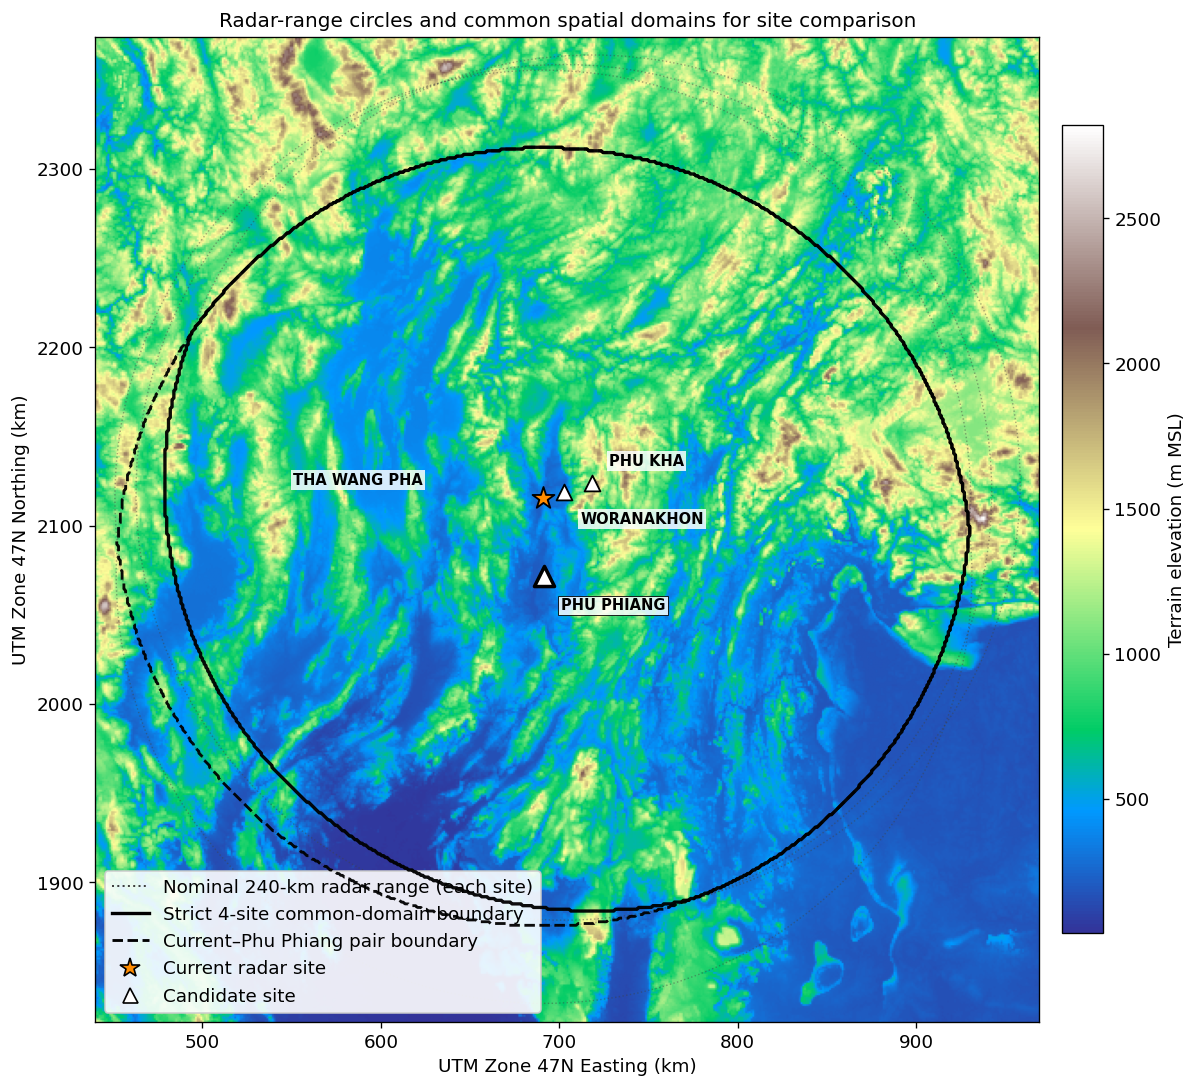

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig07_01_Radar_Ranges_and_Common_Domains_REVISED.png


In [11]:
# STEP 10 — Figure 1: true radar ranges + common-domain boundaries

extent_km = [
    dem_bounds.left / 1000.0,
    dem_bounds.right / 1000.0,
    dem_bounds.bottom / 1000.0,
    dem_bounds.top / 1000.0,
]

fig, ax = plt.subplots(figsize=(10.6, 9.2))

im = ax.imshow(
    dem,
    cmap=DEM_CMAP,
    extent=extent_km,
    origin="upper",
    zorder=0,
)

# A. True nominal radar range of EACH site
for _, row in sites.iterrows():
    sx = float(row["utm_x_m"]) / 1000.0
    sy = float(row["utm_y_m"]) / 1000.0

    add_nominal_range_circle(
        ax,
        sx,
        sy,
        linewidth=0.85,
        alpha=0.42,
        zorder=4,
    )

# B. Common-domain boundaries
add_domain_boundary(
    ax,
    common4_240,
    linestyle="-",
    linewidth=2.0,
    alpha=0.95,
    zorder=6,
)

add_domain_boundary(
    ax,
    pair_current_phu_240,
    linestyle="--",
    linewidth=1.7,
    alpha=0.95,
    zorder=6,
)

# C. Radar-site symbols and labels
label_offsets = {
    "CURRENT_THA_WANG_PHA": (-72, 11),
    "PHU_PHIANG": (10, -18),
    "WORANAKHON_PUA": (10, -16),
    "PHU_KHA_HIGH": (10, 13),
}

short_labels = {
    "CURRENT_THA_WANG_PHA": "THA WANG PHA",
    "PHU_PHIANG": "PHU PHIANG",
    "WORANAKHON_PUA": "WORANAKHON",
    "PHU_KHA_HIGH": "PHU KHA",
}

for _, row in sites.iterrows():
    role = row["site_role"]
    sx = float(row["utm_x_m"]) / 1000.0
    sy = float(row["utm_y_m"]) / 1000.0

    if role == "CURRENT_THA_WANG_PHA":
        ax.scatter(
            sx, sy,
            marker=CURRENT_MARKER,
            s=190,
            facecolor=CURRENT_FACE,
            edgecolor=CURRENT_EDGE,
            linewidth=1.1,
            zorder=9,
        )
    else:
        ax.scatter(
            sx, sy,
            marker=CANDIDATE_MARKER,
            s=145 if role == "PHU_PHIANG" else 90,
            facecolor=CANDIDATE_FACE,
            edgecolor=CANDIDATE_EDGE,
            linewidth=2.1 if role == "PHU_PHIANG" else 1.1,
            zorder=9,
        )

    dx, dy = label_offsets[role]

    ax.annotate(
        short_labels[role],
        xy=(sx, sy),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8.8,
        fontweight="bold",
        ha="left" if dx >= 0 else "right",
        va="center",
        bbox={
            "facecolor": "white",
            "edgecolor": "black" if role == "PHU_PHIANG" else "none",
            "linewidth": 0.6,
            "alpha": 0.84,
            "pad": 1.4,
        },
        zorder=10,
    )

legend_items = [
    Line2D(
        [0], [0],
        color="0.25",
        linestyle=":",
        linewidth=1.2,
        label="Nominal 240-km radar range (each site)",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        linewidth=2.0,
        label="Strict 4-site common-domain boundary",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=1.7,
        label="Current–Phu Phiang pair boundary",
    ),
    Line2D(
        [0], [0],
        marker=CURRENT_MARKER,
        linestyle="None",
        markerfacecolor=CURRENT_FACE,
        markeredgecolor=CURRENT_EDGE,
        markersize=12,
        label="Current radar site",
    ),
    Line2D(
        [0], [0],
        marker=CANDIDATE_MARKER,
        linestyle="None",
        markerfacecolor=CANDIDATE_FACE,
        markeredgecolor=CANDIDATE_EDGE,
        markersize=9,
        label="Candidate site",
    ),
]

ax.legend(
    handles=legend_items,
    loc="lower left",
    framealpha=0.90,
)

cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.82,
    pad=0.02,
)
cbar.set_label("Terrain elevation (m MSL)")

ax.set_xlabel("UTM Zone 47N Easting (km)")
ax.set_ylabel("UTM Zone 47N Northing (km)")
ax.set_title(
    "Radar-range circles and common spatial domains for site comparison"
)
ax.set_aspect("equal", adjustable="box")

fig.tight_layout()

fig1_path = (
    FIGURES_DIR /
    "Fig07_01_Radar_Ranges_and_Common_Domains_REVISED.png"
)

fig.savefig(
    fig1_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", fig1_path)

In [12]:
# STEP 11 — Reconstruct projected radar-gate geometry
az2d = np.repeat(AZIMUTHS_DEG[:, None], NBINS, axis=1)
range2d = np.repeat(RANGE_CENTERS_M[None, :], NRAYS, axis=0)

gate_geometry = {}

for _, row in sites.iterrows():
    role = row["site_role"]
    radar_altitude_msl_m = float(row["native_dem_m"]) + ANTENNA_AGL_M
    gate_geometry[role] = {}

    for elev in ELEVATIONS_DEG:
        el2d = np.full((NRAYS, NBINS), elev, dtype=float)

        coords = wrl.georef.polar.spherical_to_proj(
            range2d,
            az2d,
            el2d,
            (
                float(row["longitude"]),
                float(row["latitude"]),
                radar_altitude_msl_m,
            ),
            crs=dem_crs,
            ke=K_STANDARD,
        )

        coords = np.asarray(coords, dtype=np.float64)

        gate_geometry[role][float(elev)] = {
            "x_m": coords[..., 0].astype(np.float32),
            "y_m": coords[..., 1].astype(np.float32),
            "beam_center_msl_m": coords[..., 2].astype(np.float32),
        }

print("✓ Gate geometry reconstructed")

✓ Gate geometry reconstructed


In [13]:
# STEP 12 — Nearest-gate remapping helper
def remap_gate_field_to_common_grid(gate_x_m, gate_y_m, gate_field, domain_mask):
    valid_gate = (
        np.isfinite(gate_x_m)
        & np.isfinite(gate_y_m)
        & np.isfinite(gate_field)
    )

    points = np.column_stack([
        gate_x_m[valid_gate],
        gate_y_m[valid_gate],
    ])

    values = gate_field[valid_gate]
    tree = cKDTree(points)

    target_xy = np.column_stack([
        grid_x_m[domain_mask],
        grid_y_m[domain_mask],
    ])

    nn_distance_m, nn_index = tree.query(target_xy, k=1)

    out = np.full(grid_x_m.shape, np.nan, dtype=np.float32)
    dist = np.full(grid_x_m.shape, np.nan, dtype=np.float32)

    out[domain_mask] = values[nn_index]
    dist[domain_mask] = nn_distance_m.astype(np.float32)

    return out, dist

In [14]:
# STEP 13 — Remap all 16 scenarios
cartesian = {}
remap_qc_rows = []

for site_index, role in enumerate(required_roles):
    cartesian[role] = {}

    for elev_index, elev in enumerate(ELEVATIONS_DEG):
        geom = gate_geometry[role][float(elev)]
        polar_cbb = CBB_STACK[site_index, elev_index]

        cbb_grid, nn_dist = remap_gate_field_to_common_grid(
            geom["x_m"],
            geom["y_m"],
            polar_cbb,
            inside240[role],
        )

        beam_grid, _ = remap_gate_field_to_common_grid(
            geom["x_m"],
            geom["y_m"],
            geom["beam_center_msl_m"],
            inside240[role],
        )

        cartesian[role][float(elev)] = {
            "cbb": cbb_grid,
            "beam_center_msl_m": beam_grid,
            "nn_distance_m": nn_dist,
        }

        qvals = nn_dist[
            inside240[role] & np.isfinite(nn_dist)
        ]

        remap_qc_rows.append({
            "site_role": role,
            "elevation_deg": elev,
            "median_nn_distance_m": float(np.nanmedian(qvals)),
            "p95_nn_distance_m": float(np.nanpercentile(qvals, 95)),
            "max_nn_distance_m": float(np.nanmax(qvals)),
        })

remap_qc = pd.DataFrame(remap_qc_rows)
remap_qc_csv = TABLES_DIR / "07_CommonGrid_Remapping_Distance_QC.csv"
remap_qc.to_csv(remap_qc_csv, index=False)

display(
    remap_qc.style.format({
        "elevation_deg": "{:.1f}",
        "median_nn_distance_m": "{:.0f}",
        "p95_nn_distance_m": "{:.0f}",
        "max_nn_distance_m": "{:.0f}",
    })
)

,site_role,elevation_deg,median_nn_distance_m,p95_nn_distance_m,max_nn_distance_m
0,CURRENT_THA_WANG_PHA,0.5,630,1628,2095
1,CURRENT_THA_WANG_PHA,1.0,630,1628,2092
2,CURRENT_THA_WANG_PHA,1.5,630,1628,2097
3,CURRENT_THA_WANG_PHA,2.0,631,1628,2115
4,PHU_PHIANG,0.5,630,1633,2095
5,PHU_PHIANG,1.0,629,1633,2093
6,PHU_PHIANG,1.5,629,1633,2092
7,PHU_PHIANG,2.0,629,1633,2108
8,WORANAKHON_PUA,0.5,630,1628,2093
9,WORANAKHON_PUA,1.0,630,1628,2089


### การตีความ Remapping Distance

ถ้า p95 หรือ maximum distance เพิ่มขึ้นที่ outer range ไม่ได้หมายความว่า code ผิด แต่สะท้อน angular spacing ของ polar grid

ดังนั้น 1-km common grid เป็น analysis/display grid ไม่ใช่การอ้างว่าข้อมูลต้นทางมี resolution 1 km เท่ากันทุกระยะ

In [15]:
# STEP 14 — Common-domain metrics
common_rows = []

domains = {
    "COMMON_4SITE_100KM": common4_100,
    "COMMON_4SITE_240KM": common4_240,
}

for domain_name, domain_mask in domains.items():
    for role in required_roles:
        for elev in ELEVATIONS_DEG:
            cbb = cartesian[role][float(elev)]["cbb"]

            valid = domain_mask & np.isfinite(cbb)
            n = int(valid.sum())

            clear = valid & (cbb < CLEAR_THRESHOLD)
            partial = valid & (cbb >= CLEAR_THRESHOLD) & (cbb < SEVERE_THRESHOLD)
            severe = valid & (cbb >= SEVERE_THRESHOLD)

            common_rows.append({
                "domain": domain_name,
                "site_role": role,
                "display_name": display_name(role),
                "elevation_deg": elev,
                "valid_cells": n,
                "clear_area_pct": 100.0 * clear.sum() / n,
                "partial_area_pct": 100.0 * partial.sum() / n,
                "severe_area_pct": 100.0 * severe.sum() / n,
            })

common_metrics = pd.DataFrame(common_rows)

common_metrics_csv = TABLES_DIR / "07_CommonDomain_Site_Visibility_Metrics.csv"
common_metrics.to_csv(common_metrics_csv, index=False)

display(
    common_metrics.style.format({
        "elevation_deg": "{:.1f}",
        "clear_area_pct": "{:.2f}",
        "partial_area_pct": "{:.2f}",
        "severe_area_pct": "{:.2f}",
    })
)

,domain,site_role,display_name,elevation_deg,valid_cells,clear_area_pct,partial_area_pct,severe_area_pct
0,COMMON_4SITE_100KM,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,0.5,19036,0.18,0.37,99.44
1,COMMON_4SITE_100KM,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.0,19036,1.20,5.59,93.20
2,COMMON_4SITE_100KM,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.5,19036,9.92,20.28,69.80
3,COMMON_4SITE_100KM,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,2.0,19036,35.96,15.54,48.49
4,COMMON_4SITE_100KM,PHU_PHIANG,Phu Phiang,0.5,19036,4.41,13.19,82.40
5,COMMON_4SITE_100KM,PHU_PHIANG,Phu Phiang,1.0,19036,21.24,15.64,63.11
6,COMMON_4SITE_100KM,PHU_PHIANG,Phu Phiang,1.5,19036,43.91,14.93,41.16
7,COMMON_4SITE_100KM,PHU_PHIANG,Phu Phiang,2.0,19036,62.10,23.72,14.18
8,COMMON_4SITE_100KM,WORANAKHON_PUA,"Woranakhon, Pua",0.5,19036,3.20,8.77,88.02
9,COMMON_4SITE_100KM,WORANAKHON_PUA,"Woranakhon, Pua",1.0,19036,17.83,11.47,70.70


## Figure 2 — Clear Coverage บน Strict Common 100-km Domain

รูปนี้เป็น site-effect comparison ที่เข้มแข็งขึ้น เพราะทุก site ถูกประเมินบน ground cells ชุดเดียวกัน

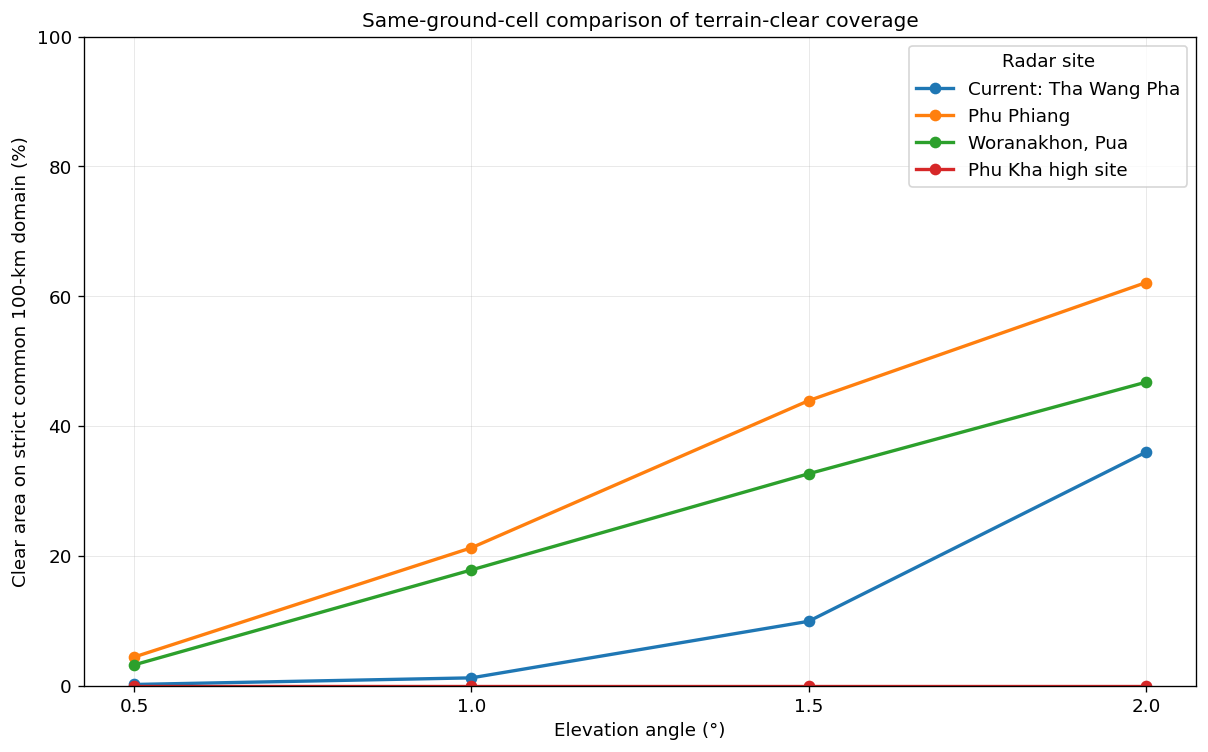

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig07_02_Common100_ClearCoverage_by_Site_and_Elevation.png


In [16]:
# STEP 15 — Figure 2: common 100-km clear coverage
sub100 = common_metrics[
    common_metrics["domain"] == "COMMON_4SITE_100KM"
]

fig, ax = plt.subplots(figsize=(10.2, 6.4))

for role in required_roles:
    sub = sub100[sub100["site_role"] == role]

    ax.plot(
        sub["elevation_deg"],
        sub["clear_area_pct"],
        marker="o",
        linewidth=2.0,
        label=display_name(role),
    )

ax.set_xticks(ELEVATIONS_DEG)
ax.set_ylim(0, 100)
ax.set_xlabel("Elevation angle (°)")
ax.set_ylabel("Clear area on strict common 100-km domain (%)")
ax.set_title("Same-ground-cell comparison of terrain-clear coverage")
ax.grid(True, linewidth=0.4, alpha=0.4)
ax.legend(title="Radar site", loc="best")

fig.tight_layout()

fig2_path = FIGURES_DIR / "Fig07_02_Common100_ClearCoverage_by_Site_and_Elevation.png"
fig.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig2_path)

# Part C — Common-Grid CBB Maps at 1.5°

ใช้ elevation 1.5° เป็น diagnostic example เพราะ Notebook 06 แสดง improvement ของ Phu Phiang เด่นชัดที่ระดับนี้

ทุก CBB map ใช้ `PuRd` และ scale 0–1 เหมือนกัน

เพื่อแยก geometry ให้ชัด:

- **พื้นที่สี CBB** = เฉพาะ strict 4-site common domain
- **เส้นดำทึบ** = strict common-domain boundary
- **เส้นจุด** = nominal 240-km radar range ของ site ที่กำลังแสดง

ดังนั้นขอบพื้นที่สีไม่ควรถูกตีความว่าเป็น radar-range circle

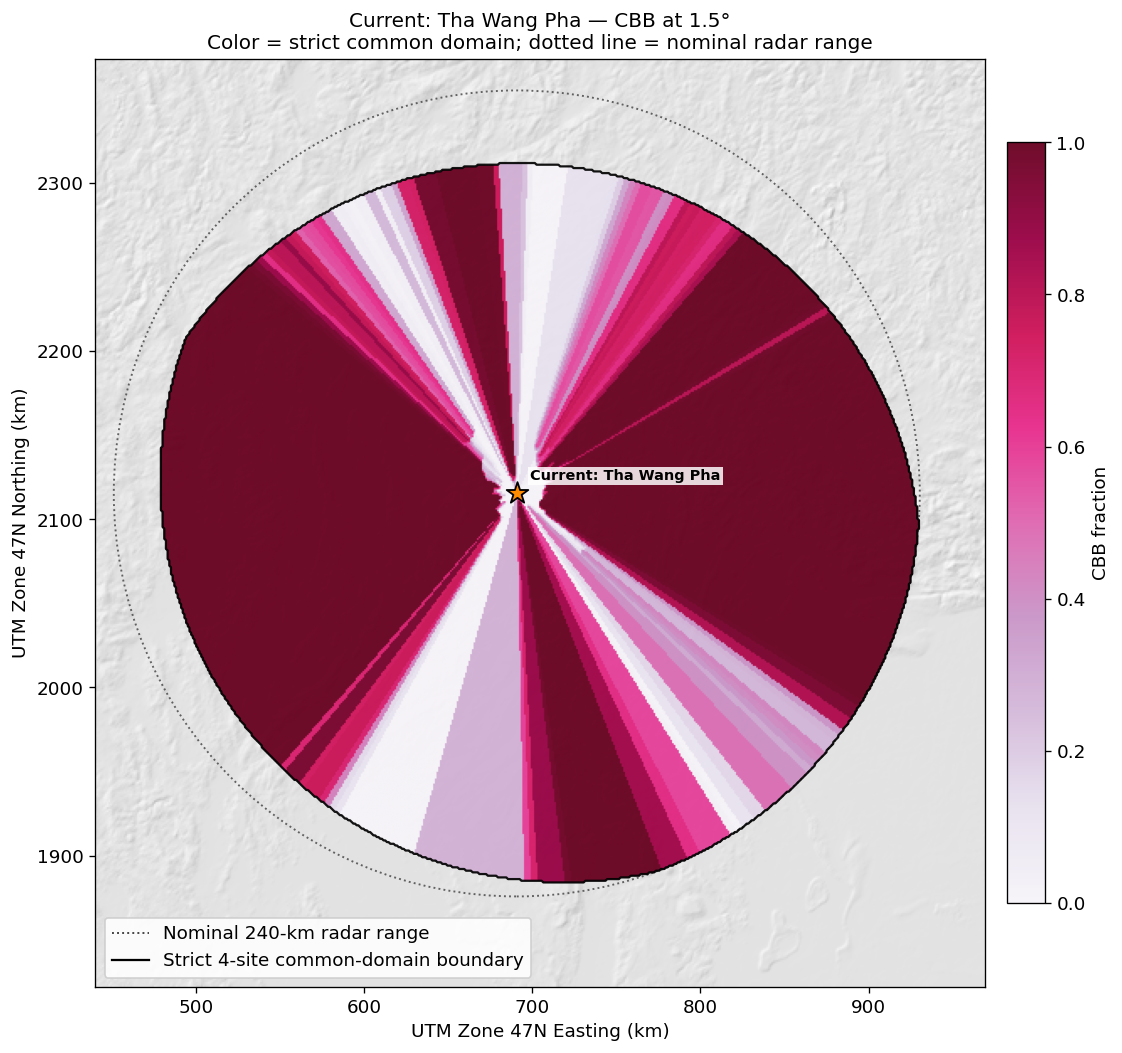

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig07_03_CURRENT_THA_WANG_PHA_CommonDomain_CBB_1p5deg_REVISED.png


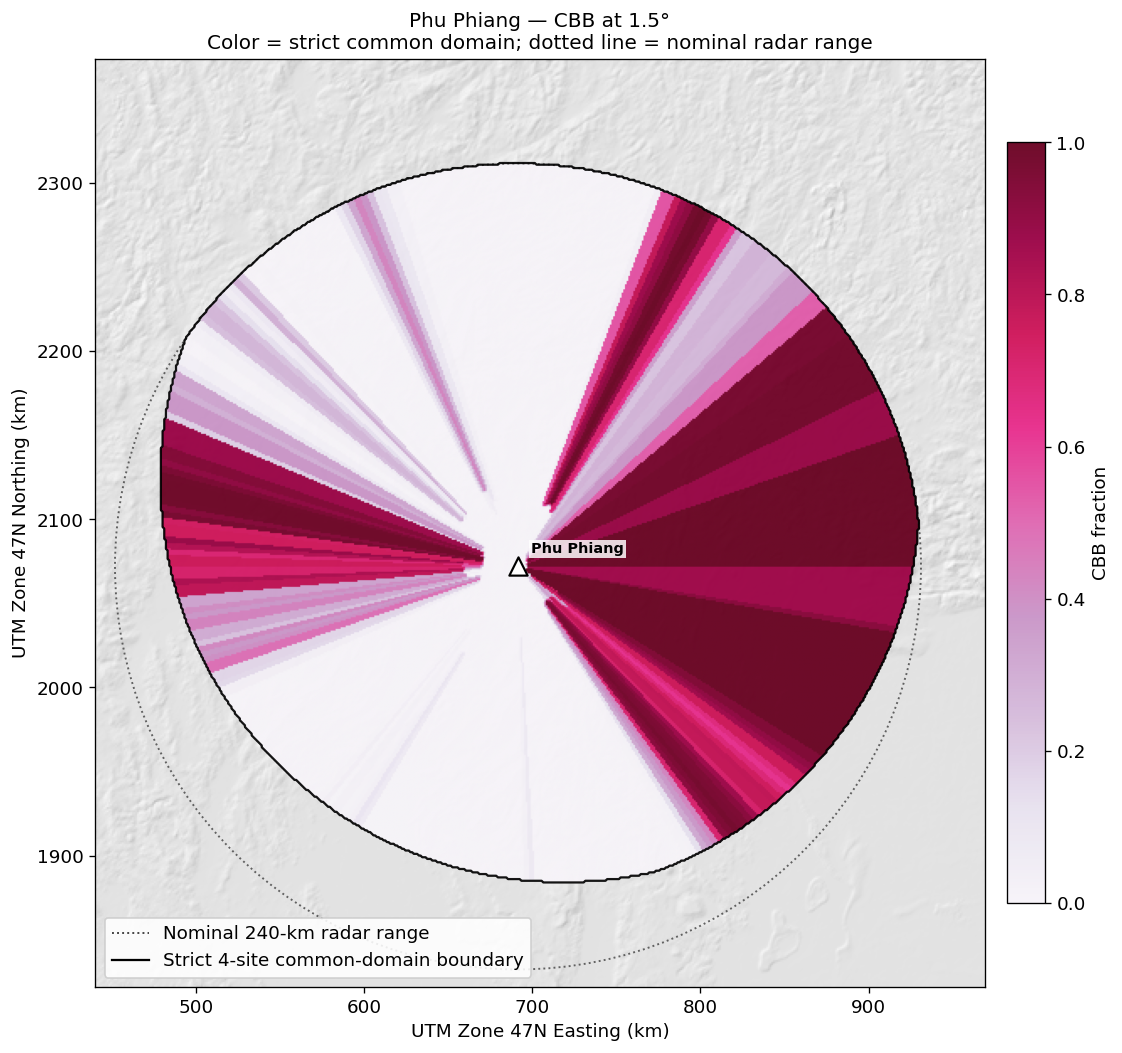

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig07_04_PHU_PHIANG_CommonDomain_CBB_1p5deg_REVISED.png


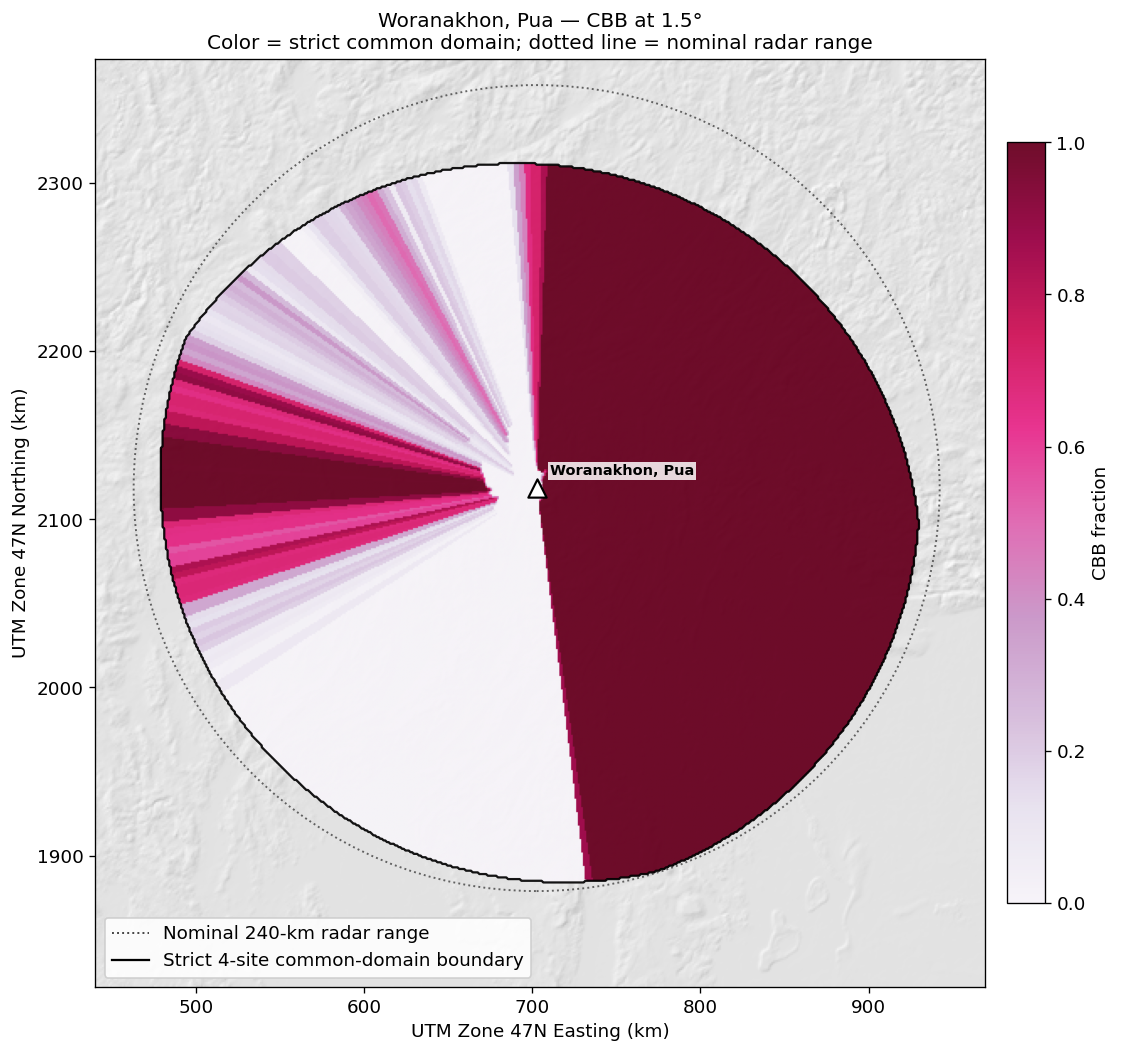

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig07_05_WORANAKHON_PUA_CommonDomain_CBB_1p5deg_REVISED.png


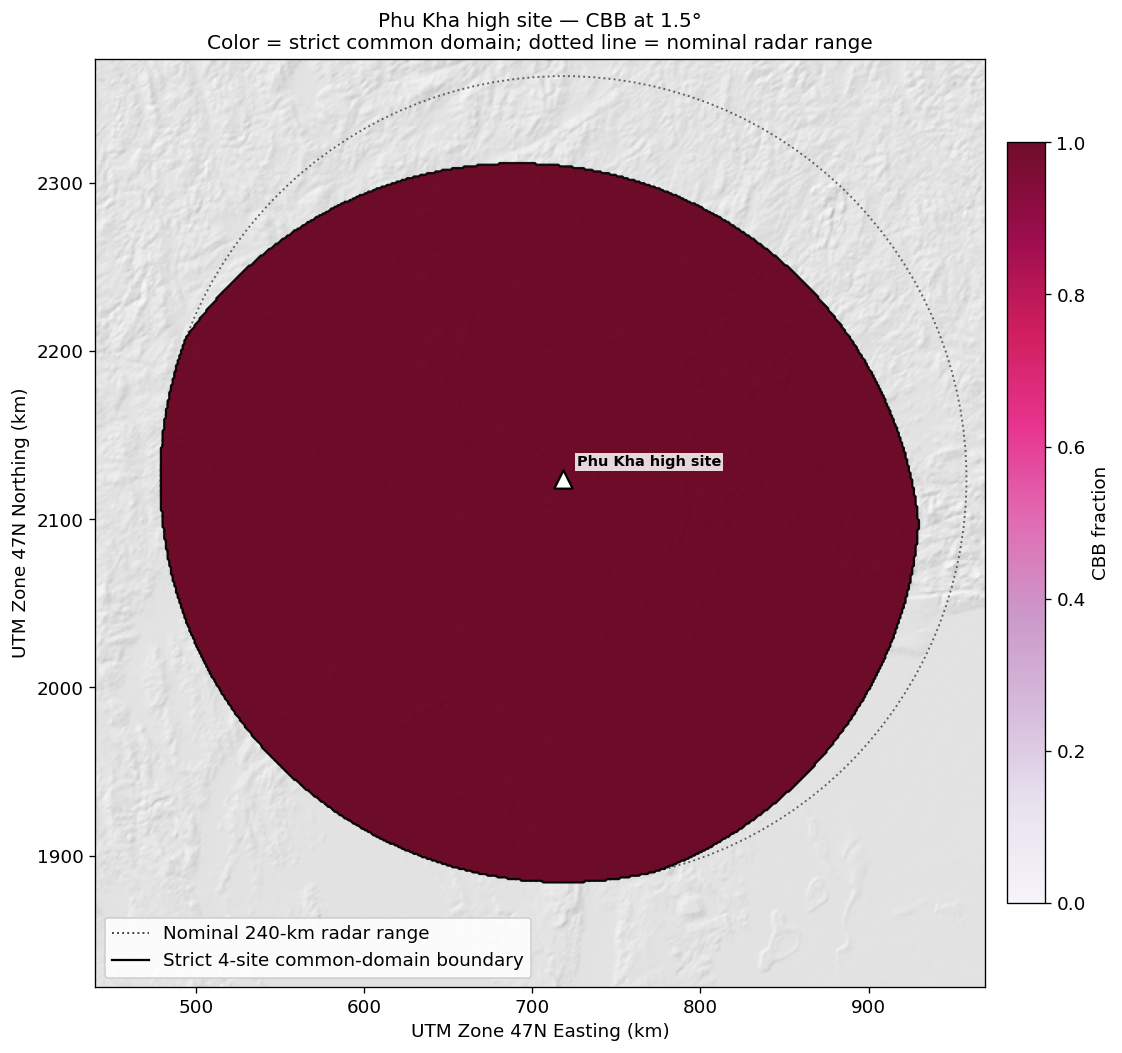

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig07_06_PHU_KHA_HIGH_CommonDomain_CBB_1p5deg_REVISED.png


In [17]:
# STEP 16 — Figures 3–6:
# Common-domain CBB at 1.5° + true radar range + common boundary

hillshade_input = np.where(
    np.isfinite(dem_data),
    dem_data,
    np.nanmedian(dem_data),
)

ls = LightSource(
    azdeg=315,
    altdeg=45,
)

hillshade = ls.hillshade(
    hillshade_input,
    vert_exag=1.0,
    dx=abs(dem_transform.a),
    dy=abs(dem_transform.e),
)

for fig_number, role in enumerate(required_roles, start=3):
    cbb = cartesian[role][1.5]["cbb"]

    plot_data = np.where(
        common4_240,
        cbb,
        np.nan,
    )

    fig, ax = plt.subplots(figsize=(10.2, 8.9))

    ax.imshow(
        hillshade,
        cmap="gray",
        extent=extent_km,
        origin="upper",
        alpha=0.30,
        zorder=0,
    )

    m = ax.imshow(
        plot_data,
        cmap=BLOCKAGE_CMAP,
        vmin=BLOCKAGE_VMIN,
        vmax=BLOCKAGE_VMAX,
        extent=extent_km,
        origin="upper",
        alpha=0.95,
        zorder=2,
    )

    row = sites[
        sites["site_role"] == role
    ].iloc[0]

    sx = float(row["utm_x_m"]) / 1000.0
    sy = float(row["utm_y_m"]) / 1000.0

    add_nominal_range_circle(
        ax,
        sx,
        sy,
        linewidth=1.15,
        alpha=0.80,
        zorder=5,
    )

    add_domain_boundary(
        ax,
        common4_240,
        linestyle="-",
        linewidth=1.35,
        alpha=0.90,
        zorder=6,
    )

    if role == "CURRENT_THA_WANG_PHA":
        ax.scatter(
            sx, sy,
            marker=CURRENT_MARKER,
            s=185,
            facecolor=CURRENT_FACE,
            edgecolor=CURRENT_EDGE,
            linewidth=1.1,
            zorder=9,
        )
    else:
        ax.scatter(
            sx, sy,
            marker=CANDIDATE_MARKER,
            s=120,
            facecolor=CANDIDATE_FACE,
            edgecolor=CANDIDATE_EDGE,
            linewidth=1.3,
            zorder=9,
        )

    ax.annotate(
        display_name(role),
        (sx, sy),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8.7,
        fontweight="bold",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.84,
            "pad": 1.2,
        },
        zorder=10,
    )

    map_legend = [
        Line2D(
            [0], [0],
            color="0.25",
            linestyle=":",
            linewidth=1.15,
            label="Nominal 240-km radar range",
        ),
        Line2D(
            [0], [0],
            color="black",
            linestyle="-",
            linewidth=1.35,
            label="Strict 4-site common-domain boundary",
        ),
    ]

    ax.legend(
        handles=map_legend,
        loc="lower left",
        framealpha=0.88,
    )

    cbar = fig.colorbar(
        m,
        ax=ax,
        shrink=0.82,
        pad=0.02,
    )
    cbar.set_label("CBB fraction")

    ax.set_xlabel("UTM Zone 47N Easting (km)")
    ax.set_ylabel("UTM Zone 47N Northing (km)")

    ax.set_title(
        f"{display_name(role)} — CBB at 1.5°\n"
        "Color = strict common domain; dotted line = nominal radar range"
    )

    ax.set_aspect("equal", adjustable="box")

    fig.tight_layout()

    path = (
        FIGURES_DIR /
        f"Fig07_{fig_number:02d}_{role}_"
        "CommonDomain_CBB_1p5deg_REVISED.png"
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", path)

# Part D — Same-Ground-Cell $\Delta CBB$

ตอนนี้สามารถคำนวณ

$$
\Delta CBB(x,y)
=
CBB_{\mathrm{PhuPhiang}}(x,y)
-
CBB_{\mathrm{Current}}(x,y)
$$

ได้อย่างมีความหมายเชิงพื้นที่

ถ้า $\Delta CBB<0$ แสดงว่า Phu Phiang มี blockage ต่ำกว่า ณ ground cell เดียวกัน

ในแผนที่นี้:

- เส้นดำทึบ = Current–Phu Phiang pairwise common-domain boundary
- เส้นจุด = nominal 240-km range ของ radar ทั้งสองสถานี

ดังนั้นขอบของพื้นที่ $\Delta CBB$ คือ intersection boundary ไม่ใช่วง radar ของสถานีใดสถานีหนึ่ง

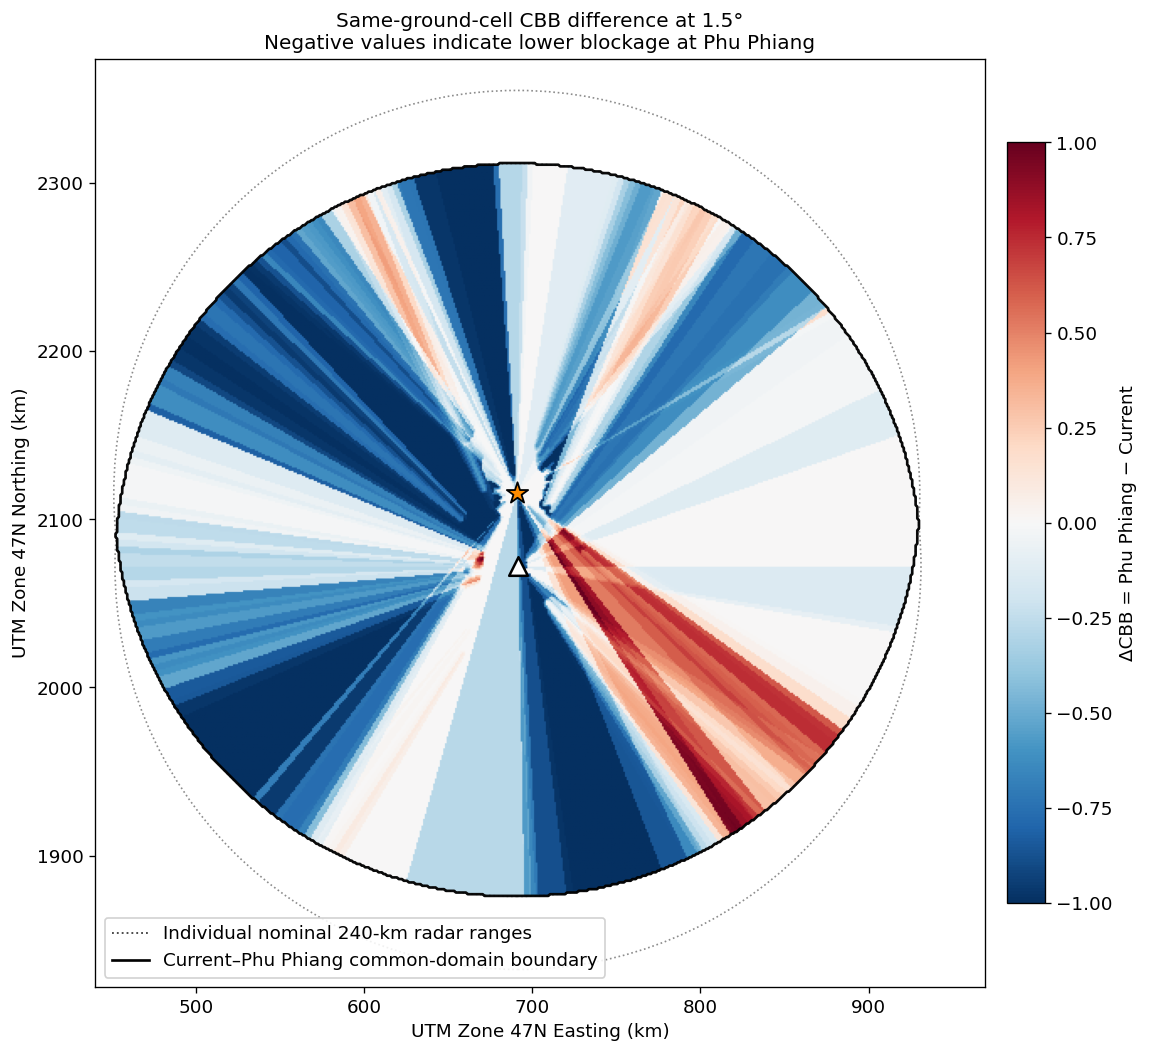

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig07_07_PhuPhiang_minus_Current_DeltaCBB_1p5deg_CommonGrid_REVISED.png


In [18]:
# STEP 17 — Figure 7:
# Same-ground-cell ΔCBB + pairwise boundary + true radar ranges

current_cbb = cartesian["CURRENT_THA_WANG_PHA"][1.5]["cbb"]
phu_cbb = cartesian["PHU_PHIANG"][1.5]["cbb"]

delta_cbb = phu_cbb - current_cbb
delta_cbb[~pair_current_phu_240] = np.nan

max_abs = max(
    float(np.nanmax(np.abs(delta_cbb))),
    0.05,
)

norm = TwoSlopeNorm(
    vmin=-max_abs,
    vcenter=0.0,
    vmax=max_abs,
)

fig, ax = plt.subplots(figsize=(10.2, 8.9))

m = ax.imshow(
    delta_cbb,
    cmap="RdBu_r",
    norm=norm,
    extent=extent_km,
    origin="upper",
    zorder=2,
)

for role in [
    "CURRENT_THA_WANG_PHA",
    "PHU_PHIANG",
]:
    row = sites[
        sites["site_role"] == role
    ].iloc[0]

    sx = float(row["utm_x_m"]) / 1000.0
    sy = float(row["utm_y_m"]) / 1000.0

    add_nominal_range_circle(
        ax,
        sx,
        sy,
        linewidth=1.0,
        alpha=0.60,
        zorder=5,
    )

    if role == "CURRENT_THA_WANG_PHA":
        ax.scatter(
            sx, sy,
            marker=CURRENT_MARKER,
            s=180,
            facecolor=CURRENT_FACE,
            edgecolor=CURRENT_EDGE,
            linewidth=1.1,
            zorder=9,
        )
    else:
        ax.scatter(
            sx, sy,
            marker=CANDIDATE_MARKER,
            s=125,
            facecolor=CANDIDATE_FACE,
            edgecolor=CANDIDATE_EDGE,
            linewidth=1.5,
            zorder=9,
        )

add_domain_boundary(
    ax,
    pair_current_phu_240,
    linestyle="-",
    linewidth=1.6,
    alpha=0.95,
    zorder=7,
)

geometry_legend = [
    Line2D(
        [0], [0],
        color="0.25",
        linestyle=":",
        linewidth=1.1,
        label="Individual nominal 240-km radar ranges",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        linewidth=1.6,
        label="Current–Phu Phiang common-domain boundary",
    ),
]

ax.legend(
    handles=geometry_legend,
    loc="lower left",
    framealpha=0.88,
)

cbar = fig.colorbar(
    m,
    ax=ax,
    shrink=0.82,
    pad=0.02,
)
cbar.set_label("ΔCBB = Phu Phiang − Current")

ax.set_xlabel("UTM Zone 47N Easting (km)")
ax.set_ylabel("UTM Zone 47N Northing (km)")

ax.set_title(
    "Same-ground-cell CBB difference at 1.5°\n"
    "Negative values indicate lower blockage at Phu Phiang"
)

ax.set_aspect("equal", adjustable="box")

fig.tight_layout()

fig7_path = (
    FIGURES_DIR /
    "Fig07_07_PhuPhiang_minus_Current_"
    "DeltaCBB_1p5deg_CommonGrid_REVISED.png"
)

fig.savefig(
    fig7_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", fig7_path)

## Visibility Transition

แบ่ง ground cells เป็น 4 สถานะ:

1. Neither clear
2. Both clear
3. **Gain at Phu Phiang**
4. **Loss at Phu Phiang**

โดย clear คือ

$$
CBB<0.10
$$

เช่นเดียวกับ $\Delta CBB$ map พื้นที่สีถูกจำกัดอยู่ใน Current–Phu Phiang pairwise common domain

เพื่อไม่ให้ขอบ domain ถูกเข้าใจว่าเป็น radar circle ภาพจะเพิ่ม nominal 240-km range ของ radar ทั้งสองเป็นเส้นจุด

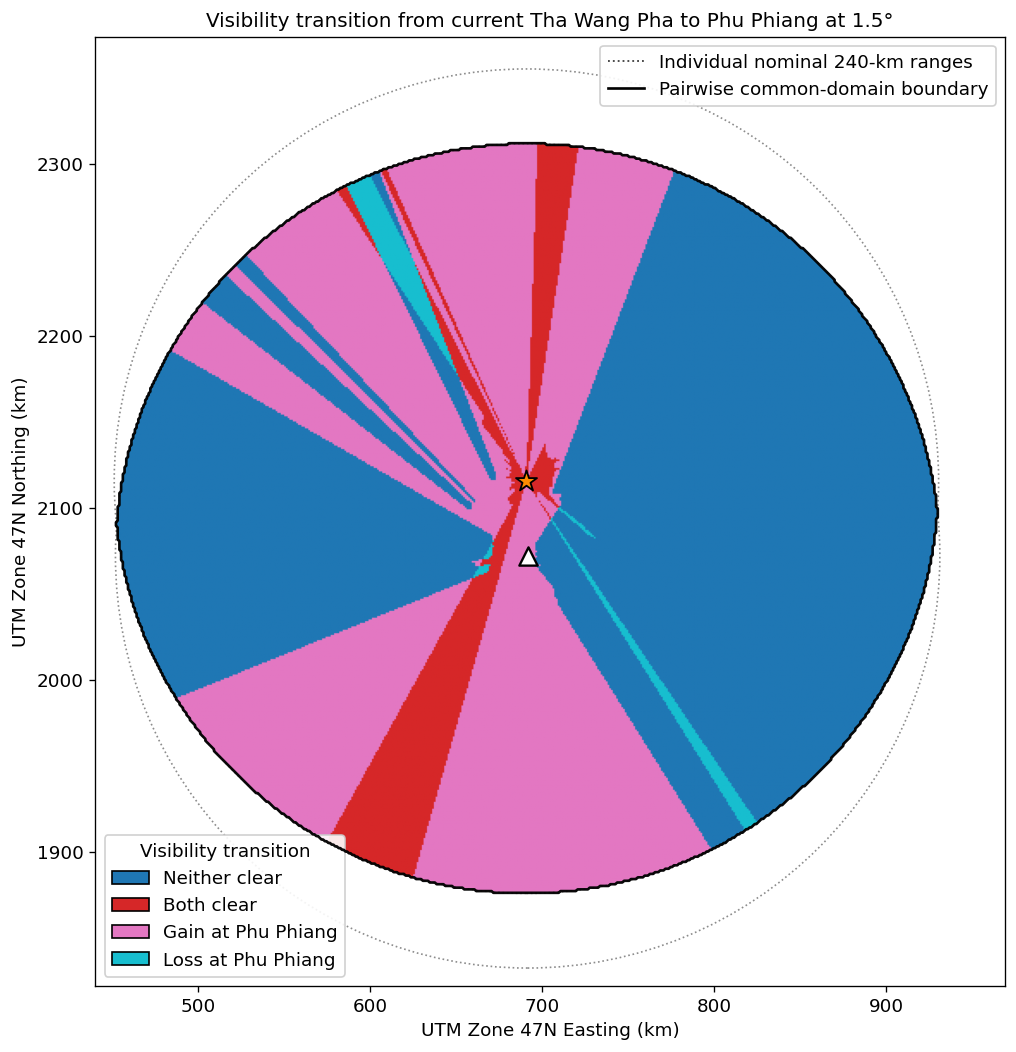

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig07_08_PhuPhiang_Visibility_Transition_1p5deg_REVISED.png


In [19]:
# STEP 18 — Figure 8:
# Visibility transition + pairwise boundary + true radar ranges

valid_pair = (
    pair_current_phu_240
    & np.isfinite(current_cbb)
    & np.isfinite(phu_cbb)
)

current_clear = current_cbb < CLEAR_THRESHOLD
phu_clear = phu_cbb < CLEAR_THRESHOLD

transition = np.full(
    current_cbb.shape,
    np.nan,
    dtype=np.float32,
)

transition[
    valid_pair
    & (~current_clear)
    & (~phu_clear)
] = 0

transition[
    valid_pair
    & current_clear
    & phu_clear
] = 1

transition[
    valid_pair
    & (~current_clear)
    & phu_clear
] = 2

transition[
    valid_pair
    & current_clear
    & (~phu_clear)
] = 3

transition_cmap = mpl.colormaps["tab10"].resampled(4)

transition_norm = mpl.colors.BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5],
    transition_cmap.N,
)

fig, ax = plt.subplots(figsize=(10.2, 8.9))

ax.imshow(
    transition,
    cmap=transition_cmap,
    norm=transition_norm,
    extent=extent_km,
    origin="upper",
    zorder=2,
)

for role in [
    "CURRENT_THA_WANG_PHA",
    "PHU_PHIANG",
]:
    row = sites[
        sites["site_role"] == role
    ].iloc[0]

    sx = float(row["utm_x_m"]) / 1000.0
    sy = float(row["utm_y_m"]) / 1000.0

    add_nominal_range_circle(
        ax,
        sx,
        sy,
        linewidth=1.0,
        alpha=0.60,
        zorder=5,
    )

    if role == "CURRENT_THA_WANG_PHA":
        ax.scatter(
            sx, sy,
            marker=CURRENT_MARKER,
            s=175,
            facecolor=CURRENT_FACE,
            edgecolor=CURRENT_EDGE,
            linewidth=1.1,
            zorder=9,
        )
    else:
        ax.scatter(
            sx, sy,
            marker=CANDIDATE_MARKER,
            s=120,
            facecolor=CANDIDATE_FACE,
            edgecolor=CANDIDATE_EDGE,
            linewidth=1.4,
            zorder=9,
        )

add_domain_boundary(
    ax,
    pair_current_phu_240,
    linestyle="-",
    linewidth=1.6,
    alpha=0.95,
    zorder=7,
)

category_labels = [
    "Neither clear",
    "Both clear",
    "Gain at Phu Phiang",
    "Loss at Phu Phiang",
]

category_patches = [
    Patch(
        facecolor=transition_cmap(i),
        edgecolor="black",
        label=label,
    )
    for i, label in enumerate(category_labels)
]

legend1 = ax.legend(
    handles=category_patches,
    loc="lower left",
    title="Visibility transition",
    framealpha=0.90,
)

ax.add_artist(legend1)

geometry_legend = [
    Line2D(
        [0], [0],
        color="0.25",
        linestyle=":",
        linewidth=1.1,
        label="Individual nominal 240-km ranges",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        linewidth=1.6,
        label="Pairwise common-domain boundary",
    ),
]

ax.legend(
    handles=geometry_legend,
    loc="upper right",
    framealpha=0.90,
)

ax.set_xlabel("UTM Zone 47N Easting (km)")
ax.set_ylabel("UTM Zone 47N Northing (km)")

ax.set_title(
    "Visibility transition from current Tha Wang Pha "
    "to Phu Phiang at 1.5°"
)

ax.set_aspect("equal", adjustable="box")

fig.tight_layout()

fig8_path = (
    FIGURES_DIR /
    "Fig07_08_PhuPhiang_Visibility_"
    "Transition_1p5deg_REVISED.png"
)

fig.savefig(
    fig8_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", fig8_path)

In [20]:
# STEP 19 — Transition statistics for all elevations
transition_rows = []

for elev in ELEVATIONS_DEG:
    cur = cartesian["CURRENT_THA_WANG_PHA"][float(elev)]["cbb"]
    phu = cartesian["PHU_PHIANG"][float(elev)]["cbb"]

    valid = (
        pair_current_phu_240
        & np.isfinite(cur)
        & np.isfinite(phu)
    )

    cur_clear = cur < CLEAR_THRESHOLD
    phu_clear = phu < CLEAR_THRESHOLD
    n = int(valid.sum())

    both_clear = valid & cur_clear & phu_clear
    gain = valid & (~cur_clear) & phu_clear
    loss = valid & cur_clear & (~phu_clear)
    neither = valid & (~cur_clear) & (~phu_clear)

    transition_rows.append({
        "elevation_deg": elev,
        "both_clear_pct": 100.0 * both_clear.sum() / n,
        "gain_at_phuphiang_pct": 100.0 * gain.sum() / n,
        "loss_at_phuphiang_pct": 100.0 * loss.sum() / n,
        "neither_clear_pct": 100.0 * neither.sum() / n,
        "net_clear_gain_pct_point": 100.0 * (gain.sum() - loss.sum()) / n,
    })

transition_summary = pd.DataFrame(transition_rows)

transition_csv = (
    TABLES_DIR /
    "07_PhuPhiang_vs_Current_CommonGrid_Visibility_Transitions.csv"
)

transition_summary.to_csv(transition_csv, index=False)

display(
    transition_summary.style.format({
        "elevation_deg": "{:.1f}",
        "both_clear_pct": "{:.2f}",
        "gain_at_phuphiang_pct": "{:.2f}",
        "loss_at_phuphiang_pct": "{:.2f}",
        "neither_clear_pct": "{:.2f}",
        "net_clear_gain_pct_point": "{:+.2f}",
    })
)

,elevation_deg,both_clear_pct,gain_at_phuphiang_pct,loss_at_phuphiang_pct,neither_clear_pct,net_clear_gain_pct_point
0,0.5,0.00,0.53,0.02,99.45,+0.51
1,1.0,0.09,18.27,0.33,81.30,+17.94
2,1.5,6.52,38.02,1.58,53.88,+36.44
3,2.0,24.35,38.91,7.87,28.87,+31.04


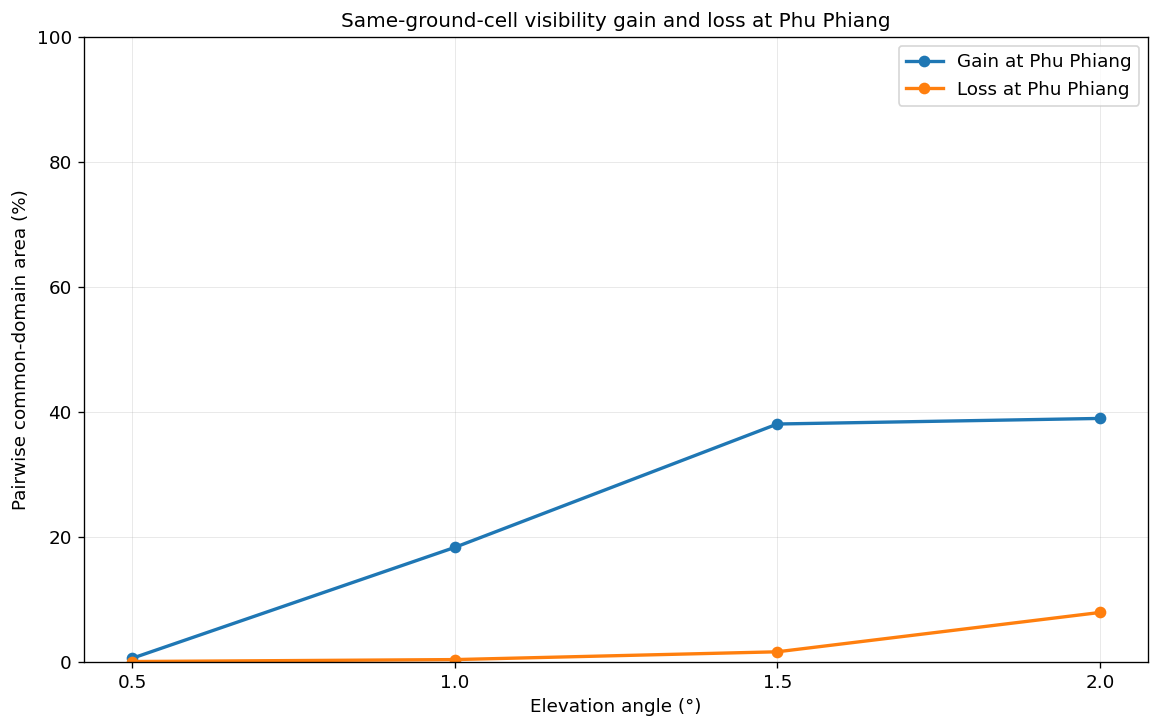

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig07_09_PhuPhiang_CommonGrid_Gain_Loss_by_Elevation.png


In [21]:
# STEP 20 — Figure 9: common-grid gain/loss by elevation
fig, ax = plt.subplots(figsize=(9.8, 6.2))

ax.plot(
    transition_summary["elevation_deg"],
    transition_summary["gain_at_phuphiang_pct"],
    marker="o",
    linewidth=2.0,
    label="Gain at Phu Phiang",
)

ax.plot(
    transition_summary["elevation_deg"],
    transition_summary["loss_at_phuphiang_pct"],
    marker="o",
    linewidth=2.0,
    label="Loss at Phu Phiang",
)

ax.set_xticks(ELEVATIONS_DEG)
ax.set_ylim(0, 100)
ax.set_xlabel("Elevation angle (°)")
ax.set_ylabel("Pairwise common-domain area (%)")
ax.set_title("Same-ground-cell visibility gain and loss at Phu Phiang")
ax.grid(True, linewidth=0.4, alpha=0.4)
ax.legend(loc="best")

fig.tight_layout()

fig9_path = FIGURES_DIR / "Fig07_09_PhuPhiang_CommonGrid_Gain_Loss_by_Elevation.png"
fig.savefig(fig9_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig9_path)

# Part E — Common-Domain MUE

MUE จะคำนวณใหม่จาก common-grid CBB เพื่อให้ทุก site มี spatial support เดียวกัน

In [22]:
# STEP 21 — Common-grid MUE
common_mue = {}
common_mue_rows = []

for role in required_roles:
    cbb_stack_site = np.stack(
        [
            cartesian[role][float(elev)]["cbb"]
            for elev in ELEVATIONS_DEG
        ],
        axis=0,
    )

    common_valid = (
        common4_240
        & np.isfinite(cbb_stack_site).all(axis=0)
    )

    mue = np.full(grid_x_m.shape, np.nan, dtype=np.float32)

    for elev_index, elev in enumerate(ELEVATIONS_DEG):
        clear = cbb_stack_site[elev_index] < CLEAR_THRESHOLD

        assign = (
            common_valid
            & np.isnan(mue)
            & clear
        )

        mue[assign] = elev

    common_mue[role] = mue
    n = int(common_valid.sum())

    for elev in ELEVATIONS_DEG:
        common_mue_rows.append({
            "site_role": role,
            "display_name": display_name(role),
            "MUE_class": f"{elev:.1f}°",
            "area_pct": (
                100.0
                * (
                    common_valid
                    & (mue == elev)
                ).sum()
                / n
            ),
        })

    common_mue_rows.append({
        "site_role": role,
        "display_name": display_name(role),
        "MUE_class": "Not clear at 0.5–2.0°",
        "area_pct": (
            100.0
            * (
                common_valid
                & np.isnan(mue)
            ).sum()
            / n
        ),
    })

common_mue_summary = pd.DataFrame(common_mue_rows)

common_mue_csv = TABLES_DIR / "07_CommonDomain_MUE_Summary.csv"
common_mue_summary.to_csv(common_mue_csv, index=False)

display(
    common_mue_summary.style.format({
        "area_pct": "{:.2f}",
    })
)

,site_role,display_name,MUE_class,area_pct
0,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,0.5°,0.02
1,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.0°,0.38
2,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.5°,7.56
3,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,2.0°,24.84
4,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,Not clear at 0.5–2.0°,67.20
5,PHU_PHIANG,Phu Phiang,0.5°,0.57
6,PHU_PHIANG,Phu Phiang,1.0°,17.61
7,PHU_PHIANG,Phu Phiang,1.5°,25.81
8,PHU_PHIANG,Phu Phiang,2.0°,18.50
9,PHU_PHIANG,Phu Phiang,Not clear at 0.5–2.0°,37.51


# Part F — Radar-Origin DEM Diagnostic

คำนวณ

$$
\Delta z_{\mathrm{site}}
=
z_{\mathrm{1km,max}}
-
z_{\mathrm{native}}
$$

และ

$$
C_{\mathrm{feed}}
=
z_{\mathrm{native}}
+
H_{\mathrm{antenna}}
-
z_{\mathrm{1km,max}}
$$

ถ้า $C_{\mathrm{feed}}<0$ coarse DEM cell สูงกว่า radar feed altitude

In [23]:
# STEP 22 — Radar-origin DEM diagnostic
site_dem_rows = []

for _, row in sites.iterrows():
    role = row["site_role"]

    rr, cc = rowcol(
        dem_transform,
        float(row["utm_x_m"]),
        float(row["utm_y_m"]),
    )

    rr = int(rr)
    cc = int(cc)

    coarse_cell_m = float(dem_data[rr, cc])
    native_m = float(row["native_dem_m"])
    feed_msl_m = native_m + ANTENNA_AGL_M

    site_dem_rows.append({
        "site_role": role,
        "display_name": row["display_name"],
        "native_site_dem_m": native_m,
        "coarse_1km_max_cell_m": coarse_cell_m,
        "coarse_minus_native_m": coarse_cell_m - native_m,
        "radar_feed_msl_m": feed_msl_m,
        "feed_minus_coarse_cell_m": feed_msl_m - coarse_cell_m,
        "feed_below_coarse_cell_max": bool(feed_msl_m < coarse_cell_m),
        "radar_dem_row": rr,
        "radar_dem_col": cc,
    })

site_dem_diagnostic = pd.DataFrame(site_dem_rows)

site_dem_csv = TABLES_DIR / "07_RadarOrigin_DEM_Consistency_Diagnostic.csv"
site_dem_diagnostic.to_csv(site_dem_csv, index=False)

display(
    site_dem_diagnostic.style.format({
        "native_site_dem_m": "{:.1f}",
        "coarse_1km_max_cell_m": "{:.1f}",
        "coarse_minus_native_m": "{:+.1f}",
        "radar_feed_msl_m": "{:.1f}",
        "feed_minus_coarse_cell_m": "{:+.1f}",
    })
)

,site_role,display_name,native_site_dem_m,coarse_1km_max_cell_m,coarse_minus_native_m,radar_feed_msl_m,feed_minus_coarse_cell_m,feed_below_coarse_cell_max,radar_dem_row,radar_dem_col
0,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,233.0,237.0,+4.0,263.0,+26.0,False,258,250
1,PHU_PHIANG,Phu Phiang,235.0,241.0,+6.0,265.0,+24.0,False,301,251
2,WORANAKHON_PUA,"Woranakhon, Pua",347.0,355.0,+8.0,377.0,+22.0,False,255,262
3,PHU_KHA_HIGH,Phu Kha high site,1296.0,1368.0,+72.0,1326.0,-42.0,True,250,278


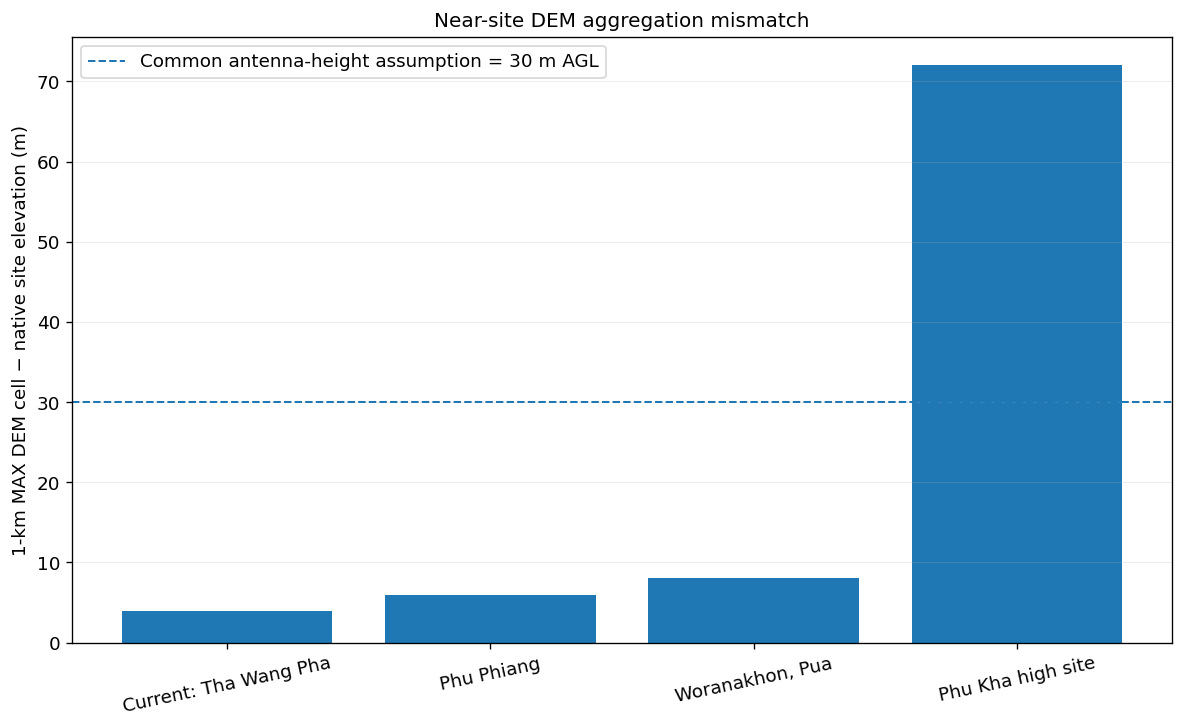

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig07_10_NearSite_DEM_Mismatch.png


In [24]:
# STEP 23 — Figure 10: near-site DEM mismatch
fig, ax = plt.subplots(figsize=(10.0, 6.2))

ax.bar(
    site_dem_diagnostic["display_name"],
    site_dem_diagnostic["coarse_minus_native_m"],
)

ax.axhline(
    ANTENNA_AGL_M,
    linestyle="--",
    linewidth=1.2,
    label=f"Common antenna-height assumption = {ANTENNA_AGL_M:.0f} m AGL",
)

ax.set_ylabel("1-km MAX DEM cell − native site elevation (m)")
ax.set_title("Near-site DEM aggregation mismatch")
ax.tick_params(axis="x", rotation=12)
ax.grid(axis="y", linewidth=0.4, alpha=0.35)
ax.legend(loc="best")

fig.tight_layout()

fig10_path = FIGURES_DIR / "Fig07_10_NearSite_DEM_Mismatch.png"
fig.savefig(fig10_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig10_path)

# Part G — Origin-Cell Sensitivity Experiment

สำหรับ gates ที่ตกใน DEM cell เดียวกับ radar origin ให้แทน terrain ด้วย native site elevation แล้วคำนวณ PBB/CBB ใหม่

ถ้าผลเปลี่ยนมาก แสดงว่า site นั้นไวต่อ near-site DEM representation

In [25]:
# STEP 24 — Helper for origin-cell corrected terrain
beam_radius_m = np.asarray(
    wrl.util.half_power_radius(
        RANGE_CENTERS_M,
        BEAMWIDTH_DEG,
    ),
    dtype=np.float32,
)

beam_radius_2d = np.broadcast_to(
    beam_radius_m[None, :],
    (NRAYS, NBINS),
)

def sample_dem_and_correct_origin_cell(gate_x_m, gate_y_m, site_row):
    flat_x = np.asarray(gate_x_m).ravel()
    flat_y = np.asarray(gate_y_m).ravel()

    rows, cols = rowcol(
        dem_transform,
        flat_x,
        flat_y,
    )

    rows = np.asarray(rows, dtype=int)
    cols = np.asarray(cols, dtype=int)

    inside = (
        (rows >= 0)
        & (rows < dem_height)
        & (cols >= 0)
        & (cols < dem_width)
    )

    terrain = np.full(
        flat_x.shape,
        np.nan,
        dtype=np.float32,
    )

    terrain[inside] = dem_data[
        rows[inside],
        cols[inside],
    ]

    radar_row, radar_col = rowcol(
        dem_transform,
        float(site_row["utm_x_m"]),
        float(site_row["utm_y_m"]),
    )

    same_origin_cell = (
        inside
        & (rows == int(radar_row))
        & (cols == int(radar_col))
    )

    terrain[same_origin_cell] = float(site_row["native_dem_m"])

    return (
        terrain.reshape(np.asarray(gate_x_m).shape),
        same_origin_cell.reshape(np.asarray(gate_x_m).shape),
    )

In [26]:
# STEP 25 — Recompute corrected CBB
corrected_cbb = {}
correction_gate_counts = []

for _, row in sites.iterrows():
    role = row["site_role"]
    corrected_cbb[role] = {}

    for elev in ELEVATIONS_DEG:
        geom = gate_geometry[role][float(elev)]

        terrain_corr, corrected_gate_mask = sample_dem_and_correct_origin_cell(
            geom["x_m"],
            geom["y_m"],
            row,
        )

        missing = ~np.isfinite(terrain_corr)
        terrain_calc = terrain_corr.copy()
        terrain_calc[missing] = -500.0

        with np.errstate(invalid="ignore", divide="ignore"):
            pbb_corr = wrl.qual.beam_block_frac(
                terrain_calc,
                geom["beam_center_msl_m"],
                beam_radius_2d,
            )

        pbb_corr = np.asarray(pbb_corr, dtype=np.float32)
        pbb_corr = np.clip(pbb_corr, 0.0, 1.0)
        pbb_corr[missing] = np.nan

        pbb_for_cbb = pbb_corr.copy()
        pbb_for_cbb[~np.isfinite(pbb_for_cbb)] = 0.0

        cbb_corr = wrl.qual.cum_beam_block_frac(
            pbb_for_cbb
        )

        cbb_corr = np.asarray(cbb_corr, dtype=np.float32)
        cbb_corr[missing] = np.nan

        corrected_cbb[role][float(elev)] = cbb_corr

        correction_gate_counts.append({
            "site_role": role,
            "elevation_deg": elev,
            "gates_replaced_in_origin_cell": int(corrected_gate_mask.sum()),
        })

correction_gate_counts = pd.DataFrame(correction_gate_counts)

print("✓ Corrected CBB scenarios calculated")

✓ Corrected CBB scenarios calculated


In [27]:
# STEP 26 — Baseline vs corrected clear-area sensitivity
delta_az_rad = np.deg2rad(1.0)

annular_sector_area_m2 = (
    0.5
    * (
        RANGE_EDGES_M[1:]**2
        - RANGE_EDGES_M[:-1]**2
    )
    * delta_az_rad
)

polar_area_weights_m2 = np.broadcast_to(
    annular_sector_area_m2[None, :],
    (NRAYS, NBINS),
)

polar_0_100 = np.broadcast_to(
    (RANGE_CENTERS_M < 100_000.0)[None, :],
    (NRAYS, NBINS),
)

sensitivity_rows = []

for site_index, role in enumerate(required_roles):
    for elev_index, elev in enumerate(ELEVATIONS_DEG):
        baseline = CBB_STACK[site_index, elev_index]
        corrected = corrected_cbb[role][float(elev)]

        for domain_name, domain_mask in [
            ("0-100km", polar_0_100),
            ("0-240km", np.ones((NRAYS, NBINS), dtype=bool)),
        ]:
            valid = (
                domain_mask
                & np.isfinite(baseline)
                & np.isfinite(corrected)
            )

            total_area = float(
                polar_area_weights_m2[valid].sum()
            )

            base_clear = valid & (baseline < CLEAR_THRESHOLD)
            corr_clear = valid & (corrected < CLEAR_THRESHOLD)

            base_clear_pct = (
                100.0
                * polar_area_weights_m2[base_clear].sum()
                / total_area
            )

            corr_clear_pct = (
                100.0
                * polar_area_weights_m2[corr_clear].sum()
                / total_area
            )

            sensitivity_rows.append({
                "site_role": role,
                "display_name": display_name(role),
                "elevation_deg": elev,
                "domain": domain_name,
                "baseline_clear_area_pct": base_clear_pct,
                "corrected_clear_area_pct": corr_clear_pct,
                "delta_clear_area_pct_point": corr_clear_pct - base_clear_pct,
            })

sensitivity_table = pd.DataFrame(sensitivity_rows)

sensitivity_csv = TABLES_DIR / "07_OriginCell_Correction_Sensitivity.csv"
sensitivity_table.to_csv(sensitivity_csv, index=False)

display(
    sensitivity_table.style.format({
        "elevation_deg": "{:.1f}",
        "baseline_clear_area_pct": "{:.2f}",
        "corrected_clear_area_pct": "{:.2f}",
        "delta_clear_area_pct_point": "{:+.2f}",
    })
)

,site_role,display_name,elevation_deg,domain,baseline_clear_area_pct,corrected_clear_area_pct,delta_clear_area_pct_point
0,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,0.5,0-100km,0.11,0.11,+0.00
1,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,0.5,0-240km,0.02,0.02,+0.00
2,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.0,0-100km,0.85,0.85,+0.00
3,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.0,0-240km,0.38,0.38,+0.00
4,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.5,0-100km,9.91,9.91,+0.00
5,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.5,0-240km,8.38,8.38,+0.00
6,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,2.0,0-100km,34.86,34.86,+0.00
7,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,2.0,0-240km,33.14,33.14,+0.00
8,PHU_PHIANG,Phu Phiang,0.5,0-100km,2.69,2.69,+0.00
9,PHU_PHIANG,Phu Phiang,0.5,0-240km,0.47,0.47,+0.00


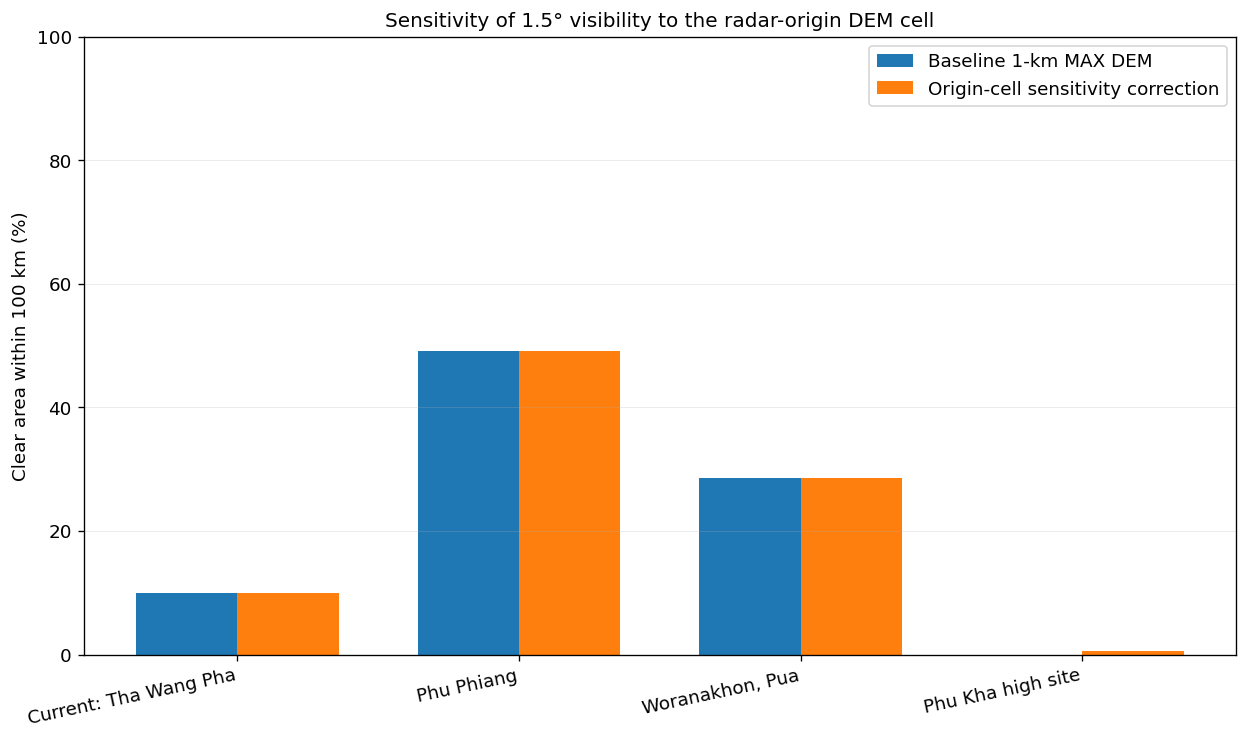

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig07_11_OriginCell_Sensitivity_1p5deg_0_100km.png


In [28]:
# STEP 27 — Figure 11: sensitivity at 1.5° within 0–100 km
sens_plot = sensitivity_table[
    (sensitivity_table["elevation_deg"] == 1.5)
    & (sensitivity_table["domain"] == "0-100km")
].copy()

x = np.arange(len(sens_plot))
width = 0.36

fig, ax = plt.subplots(figsize=(10.6, 6.3))

ax.bar(
    x - width / 2.0,
    sens_plot["baseline_clear_area_pct"],
    width=width,
    label="Baseline 1-km MAX DEM",
)

ax.bar(
    x + width / 2.0,
    sens_plot["corrected_clear_area_pct"],
    width=width,
    label="Origin-cell sensitivity correction",
)

ax.set_xticks(
    x,
    sens_plot["display_name"],
    rotation=12,
    ha="right",
)

ax.set_ylim(0, 100)
ax.set_ylabel("Clear area within 100 km (%)")
ax.set_title("Sensitivity of 1.5° visibility to the radar-origin DEM cell")
ax.grid(axis="y", linewidth=0.4, alpha=0.35)
ax.legend(loc="best")

fig.tight_layout()

fig11_path = FIGURES_DIR / "Fig07_11_OriginCell_Sensitivity_1p5deg_0_100km.png"
fig.savefig(fig11_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig11_path)

# Part H — Beam Altitude เป็น Counterbalance ต่อ Visibility

site บนภูเขาสูงอาจมี terrain visibility ดี แต่ beam absolute altitude สูงขึ้นตั้งแต่ต้น

จึงควรรายงาน beam-centre altitude ร่วมกับ blockage metrics

In [29]:
# STEP 28 — Beam-centre altitude at 100 km
range_idx_100 = int(
    np.argmin(
        np.abs(RANGE_CENTERS_M / 1000.0 - 100.0)
    )
)

beam100_rows = []

for _, row in sites.iterrows():
    role = row["site_role"]

    for elev in ELEVATIONS_DEG:
        beam_profile = gate_geometry[role][float(elev)]["beam_center_msl_m"][0, :]
        beam_msl = float(beam_profile[range_idx_100])

        beam100_rows.append({
            "site_role": role,
            "display_name": row["display_name"],
            "ground_elevation_msl_m": float(row["native_dem_m"]),
            "elevation_deg": elev,
            "actual_gate_range_km": float(RANGE_CENTERS_M[range_idx_100] / 1000.0),
            "beam_center_msl_m": beam_msl,
            "beam_center_above_site_ground_m": beam_msl - float(row["native_dem_m"]),
        })

beam100_table = pd.DataFrame(beam100_rows)

beam100_csv = TABLES_DIR / "07_BeamCentre_Altitude_at_100km.csv"
beam100_table.to_csv(beam100_csv, index=False)

display(
    beam100_table.style.format({
        "ground_elevation_msl_m": "{:.1f}",
        "elevation_deg": "{:.1f}",
        "actual_gate_range_km": "{:.2f}",
        "beam_center_msl_m": "{:.1f}",
        "beam_center_above_site_ground_m": "{:.1f}",
    })
)

,site_role,display_name,ground_elevation_msl_m,elevation_deg,actual_gate_range_km,beam_center_msl_m,beam_center_above_site_ground_m
0,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,233.0,0.5,99.75,1718.5,1485.5
1,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,233.0,1.0,99.75,2588.8,2355.8
2,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,233.0,1.5,99.75,3458.8,3225.8
3,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,233.0,2.0,99.75,4328.5,4095.5
4,PHU_PHIANG,Phu Phiang,235.0,0.5,99.75,1720.5,1485.5
5,PHU_PHIANG,Phu Phiang,235.0,1.0,99.75,2590.8,2355.8
6,PHU_PHIANG,Phu Phiang,235.0,1.5,99.75,3460.7,3225.7
7,PHU_PHIANG,Phu Phiang,235.0,2.0,99.75,4330.4,4095.4
8,WORANAKHON_PUA,"Woranakhon, Pua",347.0,0.5,99.75,1832.5,1485.5
9,WORANAKHON_PUA,"Woranakhon, Pua",347.0,1.0,99.75,2702.8,2355.8


# Part I — Evidence Matrix

ใช้ 1.5° เป็นตัวอย่างหลัก และสรุป

- strict-common 100-km clear/severe coverage
- strict-common 240-km clear coverage
- common-domain MUE not-clear fraction
- beam altitude ที่ 100 km
- DEM mismatch
- origin-cell sensitivity

โดยยังไม่สร้าง composite score

In [30]:
# STEP 29 — Build transparent decision-evidence matrix
EVIDENCE_ELEVATION = 1.5

common100_ev = common_metrics[
    (common_metrics["domain"] == "COMMON_4SITE_100KM")
    & (common_metrics["elevation_deg"] == EVIDENCE_ELEVATION)
][
    ["site_role", "clear_area_pct", "severe_area_pct"]
].rename(
    columns={
        "clear_area_pct": "common100_clear_pct",
        "severe_area_pct": "common100_severe_pct",
    }
)

common240_ev = common_metrics[
    (common_metrics["domain"] == "COMMON_4SITE_240KM")
    & (common_metrics["elevation_deg"] == EVIDENCE_ELEVATION)
][
    ["site_role", "clear_area_pct"]
].rename(
    columns={
        "clear_area_pct": "common240_clear_pct",
    }
)

mue_notclear = common_mue_summary[
    common_mue_summary["MUE_class"] == "Not clear at 0.5–2.0°"
][
    ["site_role", "area_pct"]
].rename(
    columns={
        "area_pct": "common240_mue_not_clear_pct",
    }
)

beam_ev = beam100_table[
    beam100_table["elevation_deg"] == EVIDENCE_ELEVATION
][
    [
        "site_role",
        "beam_center_msl_m",
        "beam_center_above_site_ground_m",
    ]
]

dem_ev = site_dem_diagnostic[
    [
        "site_role",
        "coarse_minus_native_m",
        "feed_minus_coarse_cell_m",
        "feed_below_coarse_cell_max",
    ]
]

sens_ev = sensitivity_table[
    (sensitivity_table["elevation_deg"] == EVIDENCE_ELEVATION)
    & (sensitivity_table["domain"] == "0-100km")
][
    ["site_role", "delta_clear_area_pct_point"]
].rename(
    columns={
        "delta_clear_area_pct_point":
        "origin_cell_sensitivity_delta_clear100_pp",
    }
)

evidence_matrix = (
    sites[
        ["site_role", "display_name", "native_dem_m"]
    ]
    .rename(columns={"native_dem_m": "ground_elevation_msl_m"})
    .merge(common100_ev, on="site_role", how="left")
    .merge(common240_ev, on="site_role", how="left")
    .merge(mue_notclear, on="site_role", how="left")
    .merge(beam_ev, on="site_role", how="left")
    .merge(dem_ev, on="site_role", how="left")
    .merge(sens_ev, on="site_role", how="left")
)

evidence_csv = TABLES_DIR / "07_Radar_Site_Decision_Evidence_Matrix.csv"
evidence_matrix.to_csv(evidence_csv, index=False)

display(
    evidence_matrix.style.format({
        "ground_elevation_msl_m": "{:.1f}",
        "common100_clear_pct": "{:.2f}",
        "common100_severe_pct": "{:.2f}",
        "common240_clear_pct": "{:.2f}",
        "common240_mue_not_clear_pct": "{:.2f}",
        "beam_center_msl_m": "{:.1f}",
        "beam_center_above_site_ground_m": "{:.1f}",
        "coarse_minus_native_m": "{:+.1f}",
        "feed_minus_coarse_cell_m": "{:+.1f}",
        "origin_cell_sensitivity_delta_clear100_pp": "{:+.2f}",
    })
)

,site_role,display_name,ground_elevation_msl_m,common100_clear_pct,common100_severe_pct,common240_clear_pct,common240_mue_not_clear_pct,beam_center_msl_m,beam_center_above_site_ground_m,coarse_minus_native_m,feed_minus_coarse_cell_m,feed_below_coarse_cell_max,origin_cell_sensitivity_delta_clear100_pp
0,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,233.0,9.92,69.80,7.96,67.20,3458.8,3225.8,+4.0,+26.0,False,+0.00
1,PHU_PHIANG,Phu Phiang,235.0,43.91,41.16,43.99,37.51,3460.7,3225.7,+6.0,+24.0,False,+0.00
2,WORANAKHON_PUA,"Woranakhon, Pua",347.0,32.65,57.58,27.63,54.59,3572.7,3225.7,+8.0,+22.0,False,+0.00
3,PHU_KHA_HIGH,Phu Kha high site,1296.0,0.00,100.00,0.00,100.00,4521.7,3225.7,+72.0,-42.0,True,+0.56


### วิธีอ่าน Evidence Matrix

- `common100_clear_pct` สูง → near-range terrain visibility ดี
- `common100_severe_pct` ต่ำ → severe blockage น้อย
- `common240_mue_not_clear_pct` ต่ำ → พื้นที่ recover ได้มากด้วย elevation ≤2°
- `beam_center_msl_m` สูงมาก → ระวัง low-level sampling
- `feed_below_coarse_cell_max=True` → near-site DEM representation น่าสงสัย
- `origin_cell_sensitivity_delta_clear100_pp` สูง → ranking ไวต่อ DEM treatment

In [31]:
# STEP 30 — Save common-grid arrays
common_cbb_stack = np.stack(
    [
        np.stack(
            [
                cartesian[role][float(elev)]["cbb"]
                for elev in ELEVATIONS_DEG
            ],
            axis=0,
        )
        for role in required_roles
    ],
    axis=0,
).astype(np.float32)

common_mue_stack = np.stack(
    [common_mue[role] for role in required_roles],
    axis=0,
).astype(np.float32)

cartesian_output = (
    RESULTS_DIR /
    "07_CommonCartesian_CBB_4sites_4elevations.npz"
)

np.savez_compressed(
    cartesian_output,
    site_roles=np.asarray(required_roles, dtype=object),
    elevations_deg=ELEVATIONS_DEG,
    x_centers_m=x_centers_m,
    y_centers_m=y_centers_m,
    dem_msl_m=dem_data,
    strict_common_240_mask=common4_240,
    strict_common_100_mask=common4_100,
    current_phuphiang_pair_240_mask=pair_current_phu_240,
    current_phuphiang_pair_100_mask=pair_current_phu_100,
    cbb_common_grid=common_cbb_stack,
    mue_common_grid=common_mue_stack,
)

print("Saved:", cartesian_output)
print("CBB common-grid stack:", common_cbb_stack.shape)

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/03_results/07_CommonCartesian_CBB_4sites_4elevations.npz
CBB common-grid stack: (4, 4, 552, 529)


# Part J — การตีความเชิงงานวิจัย

ถ้า Phu Phiang ยังมี

$$
A_{\mathrm{clear,PhuPhiang}}
>
A_{\mathrm{clear,Current}}
$$

บน strict common domain แสดงว่า improvement ยังปรากฏเมื่อเปรียบเทียบ ground locations ชุดเดียวกันจริง

ถ้า Phu Kha เปลี่ยนมากหลัง origin-cell correction แสดงว่า baseline result มีความไวต่อ DEM representation สูง และไม่ควรใช้เพื่อ final ranking โดยไม่ตรวจ DEM เพิ่ม

## แบบฝึกคิด

### CORE

1. Phu Phiang ยังมี common-domain clear coverage สูงกว่า current ที่ 1.5° หรือไม่?
2. บริเวณใดใน transition map เป็น `Gain at Phu Phiang`?
3. remapping distance เพิ่มตาม range เพราะเหตุใด?
4. site ใดมี coarse DEM mismatch มากที่สุด?

### ADVANCED

5. เปรียบเทียบ baseline กับ origin-cell correction ของ Phu Kha
6. อธิบายว่าทำไม correction นี้เป็นเพียง sensitivity test
7. เปรียบเทียบ `common100_clear_pct` กับ beam altitude ที่ 100 km

### RESEARCH EXTENSION

8. เปลี่ยน common grid เป็น 2 km แล้วตรวจความเสถียรของผล
9. ทดลอง bilinear หรือ inverse-distance remapping
10. เพิ่ม administrative boundary หรือ basin boundary เพื่อประเมินเฉพาะพื้นที่เป้าหมาย

In [32]:
# STEP 31 — Save metadata and final readiness check
metadata = {
    "notebook": "07_Radar_Site_Decision_Support_and_Common_Domain_Spatial_Evaluation",
    "common_grid_crs": str(dem_crs),
    "common_grid_resolution_m": [
        float(abs(dem_transform.a)),
        float(abs(dem_transform.e)),
    ],
    "common_radius_km": COMMON_RADIUS_M / 1000.0,
    "strict_common_240_area_km2": float(common4_240.sum() * cell_area_km2),
    "strict_common_100_area_km2": float(common4_100.sum() * cell_area_km2),
    "pair_current_phuphiang_240_area_km2": float(
        pair_current_phu_240.sum() * cell_area_km2
    ),
    "remapping_method": "Nearest projected radar gate using scipy.spatial.cKDTree",
    "clear_threshold": CLEAR_THRESHOLD,
    "severe_threshold": SEVERE_THRESHOLD,
    "site_cell_sensitivity_test": (
        "Replace terrain for gates inside the radar-origin 1-km DEM cell "
        "with native site elevation; diagnostic only."
    ),
    "decision_support_principle": (
        "Scientific evidence retained separately from mission-specific weighting."
    ),
    "wradlib_version": wrl.__version__,
    "source_multisite_npz": str(MULTISITE_NPZ),
    "common_cartesian_npz": str(cartesian_output),
    "common_metrics_csv": str(common_metrics_csv),
    "remap_qc_csv": str(remap_qc_csv),
    "transition_csv": str(transition_csv),
    "common_mue_csv": str(common_mue_csv),
    "site_dem_csv": str(site_dem_csv),
    "sensitivity_csv": str(sensitivity_csv),
    "beam100_csv": str(beam100_csv),
    "evidence_csv": str(evidence_csv),
}

metadata_path = (
    METADATA_DIR /
    "07_CommonDomain_DecisionSupport_Metadata.json"
)

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

final_checks = {
    "Four site roles resolved": len(sites) == 4,
    "Common 240-km domain non-empty": bool(common4_240.any()),
    "Common 100-km domain non-empty": bool(common4_100.any()),
    "Current–Phu pair domain non-empty": bool(pair_current_phu_240.any()),
    "All 16 scenarios remapped": sum(
        len(cartesian[role])
        for role in required_roles
    ) == 16,
    "Common metrics saved": common_metrics_csv.exists(),
    "Remapping QC saved": remap_qc_csv.exists(),
    "Transition summary saved": transition_csv.exists(),
    "Common MUE saved": common_mue_csv.exists(),
    "DEM diagnostic saved": site_dem_csv.exists(),
    "Sensitivity table saved": sensitivity_csv.exists(),
    "Beam-altitude table saved": beam100_csv.exists(),
    "Evidence matrix saved": evidence_csv.exists(),
    "Cartesian NPZ saved": cartesian_output.exists(),
    "Metadata JSON saved": metadata_path.exists(),
}

print("=" * 92)
print("NOTEBOOK 07 — FINAL READINESS CHECK")
print("=" * 92)

all_ok = True

for label, status in final_checks.items():
    print(("✓" if status else "✗"), label)
    all_ok = all_ok and status

print("=" * 92)

if all_ok:
    print(
        "\n✓ COMMON-DOMAIN DECISION SUPPORT READY — proceed to "
        "Notebook 08: DEM/tower-height uncertainty and mission-specific sensitivity."
    )
else:
    raise RuntimeError("One or more Notebook 07 checks failed.")

NOTEBOOK 07 — FINAL READINESS CHECK
✓ Four site roles resolved
✓ Common 240-km domain non-empty
✓ Common 100-km domain non-empty
✓ Current–Phu pair domain non-empty
✓ All 16 scenarios remapped
✓ Common metrics saved
✓ Remapping QC saved
✓ Transition summary saved
✓ Common MUE saved
✓ DEM diagnostic saved
✓ Sensitivity table saved
✓ Beam-altitude table saved
✓ Evidence matrix saved
✓ Cartesian NPZ saved
✓ Metadata JSON saved

✓ COMMON-DOMAIN DECISION SUPPORT READY — proceed to Notebook 08: DEM/tower-height uncertainty and mission-specific sensitivity.


# สรุปบทเรียน

Notebook นี้เปลี่ยนจาก

$$
\mathrm{same\ polar\ index}
$$

ไปเป็น

$$
\mathrm{same\ ground\ cell}
$$

และเพิ่ม near-site DEM sensitivity

workflow หลักคือ

$$
\boxed{
CBB_{\mathrm{polar}}
\rightarrow
CBB_{\mathrm{common\ Cartesian}}
\rightarrow
\Delta CBB
\rightarrow
\mathrm{Visibility\ transition}
\rightarrow
\mathrm{DEM\ sensitivity}
\rightarrow
\mathrm{Evidence\ matrix}
}
$$

### Output หลัก

```text
03_results/
└── 07_CommonCartesian_CBB_4sites_4elevations.npz

05_tables/
├── 07_CommonGrid_Remapping_Distance_QC.csv
├── 07_CommonDomain_Site_Visibility_Metrics.csv
├── 07_PhuPhiang_vs_Current_CommonGrid_Visibility_Transitions.csv
├── 07_CommonDomain_MUE_Summary.csv
├── 07_RadarOrigin_DEM_Consistency_Diagnostic.csv
├── 07_OriginCell_Correction_Sensitivity.csv
├── 07_BeamCentre_Altitude_at_100km.csv
└── 07_Radar_Site_Decision_Evidence_Matrix.csv

02_metadata/
└── 07_CommonDomain_DecisionSupport_Metadata.json
```

## Next — Notebook 08

**DEM Resolution, Tower Height and Site-Selection Uncertainty**

เพื่อทดสอบความเสถียรของข้อสรุปเมื่อเปลี่ยน antenna height และ near-field terrain representation ก่อนสร้าง mission-specific decision scenarios

### Cartographic clarification added in this revision

ตั้งแต่ revision นี้เป็นต้นไป

$$
\boxed{
\mathrm{Radar\ range\ circle}
\neq
\mathrm{Common\ domain\ boundary}
}
$$

- เส้นจุด = nominal radar range ของสถานี
- เส้นทึบ/ประที่หนากว่า = intersection-based common-domain boundary
- พื้นที่สี CBB / $\Delta CBB$ / transition ถูกจำกัดตาม common domain ที่ระบุ

จึงสามารถใช้ figures เพื่อสอน geometry ของ radar coverage และ common-domain GIS analysis ได้โดยไม่ทำให้ผู้เรียนเข้าใจว่าขอบ intersection เป็น “วงกลม radar ที่เบี้ยว”